In [1]:
import brainsss
import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import colors
%matplotlib inline
#from sklearn.cluster import AgglomerativeClustering
import scipy
import time
import h5py
import ants
import nibabel as nib
from scipy.ndimage import uniform_filter, gaussian_filter
import shutil
from sklearn.cluster import AgglomerativeClustering
from sklearn.feature_extraction.image import grid_to_graph
import gc
import sys
import warnings
from scipy.ndimage import gaussian_filter1d,gaussian_filter
from scipy.signal import butter, sosfiltfilt, filtfilt, freqz,iirnotch
import cv2
from scipy.ndimage.morphology import binary_erosion
from scipy.ndimage.morphology import binary_dilation
from scipy.ndimage import zoom
from sklearn.mixture import GaussianMixture
import scipy.stats as stats
import sklearn
import pickle
import itertools
from statsmodels.stats.multitest import multipletests
import seaborn as sns
import pandas as pd
from skimage import measure
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from scipy.ndimage.morphology import binary_erosion, binary_dilation
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import pdist
import csv
from functools import reduce
from sklearn.decomposition import PCA
import multiprocessing as mp
from multiprocessing import Pool

In [2]:
color_map_color_1=np.asarray(['#780000','#C1121F','#E0898F','#F0C4C7','#FFFFFF','#D9E6EF','#B3CDDE','#669BBC', '#003049'])[::-1]
cmap_personal = matplotlib.colors.LinearSegmentedColormap.from_list(
    'cmap', color_map_color_1)

In [3]:
home_path = '/oak/stanford/groups/trc/data/Ilana/2P/data/later/'
later_dir = '/oak/stanford/groups/trc/data/Ilana/2P/data/later/temp_filter'
cluster_dir = os.path.join(later_dir, 'clustering')
save_dir=os.path.join(later_dir,'figs')
# Suppress RuntimeWarning
warnings.filterwarnings('ignore', category=RuntimeWarning)

In [4]:
event1='best_5sec'
# event2='best'
n_clusters=500
label_files=[]
cluster_files=[]
for file in os.listdir(cluster_dir):
#     print(file)
    if f'_{n_clusters}' in file and 'labels' in file and 'total' in file:
        label_files.append(file)
    elif f'_{n_clusters}_' in file and 'clusters' in file and event1 in file and 'new' not in file:
        cluster_files.append(file)

## Load supervox

In [5]:
cluster_files

['superclust_clusters_500_best_5sec.pkl']

In [6]:
%%time
best_cluster_path_5sec=os.path.join(cluster_dir,cluster_files[0])
# best_cluster_path=os.path.join(cluster_dir,cluster_files[1])
print(best_cluster_path_5sec)
with open(best_cluster_path_5sec, 'rb') as file:
    five_sec = pickle.load(file)
    print(five_sec.keys())

# with open(best_cluster_path, 'rb') as file:
#     best = pickle.load(file)
#     print(best.keys())
    

/oak/stanford/groups/trc/data/Ilana/2P/data/later/temp_filter/clustering/superclust_clusters_500_best_5sec.pkl
dict_keys(['inc', 'dec', 'flat'])
CPU times: user 0 ns, sys: 2.59 ms, total: 2.59 ms
Wall time: 53.3 ms


In [7]:
label_files

['supercluster_labels_total_500.npy']

In [8]:
%%time
best_label_path=os.path.join(cluster_dir,label_files[0])
print(best_label_path)
giant_total_labels=np.load(best_label_path)
print(giant_total_labels.shape)

/oak/stanford/groups/trc/data/Ilana/2P/data/later/temp_filter/clustering/supercluster_labels_total_500.npy
(4171804,)
CPU times: user 1.12 ms, sys: 10.2 ms, total: 11.3 ms
Wall time: 11.6 ms


In [9]:
giant_total_anat=giant_total_labels.reshape(314,146,91)


In [10]:
rainbow_color=np.asarray(['#FFFFFF','#EF476F', '#F78C6B', '#FFD166', '#06D6A0','#118AB2','#6A4C93','#6d0d25']) #,  '#6d0d25'
# cmap_rainbow = matplotlib.colors.LinearSegmentedColormap.from_list(
#     'cmap', rainbow_color)
cmap_rainbow = matplotlib.colors.ListedColormap(rainbow_color)

In [11]:
giant_total_anat.shape

(314, 146, 91)

In [12]:
fixed = brainsss.load_fda_meanbrain()
behaviors=list(five_sec.keys())

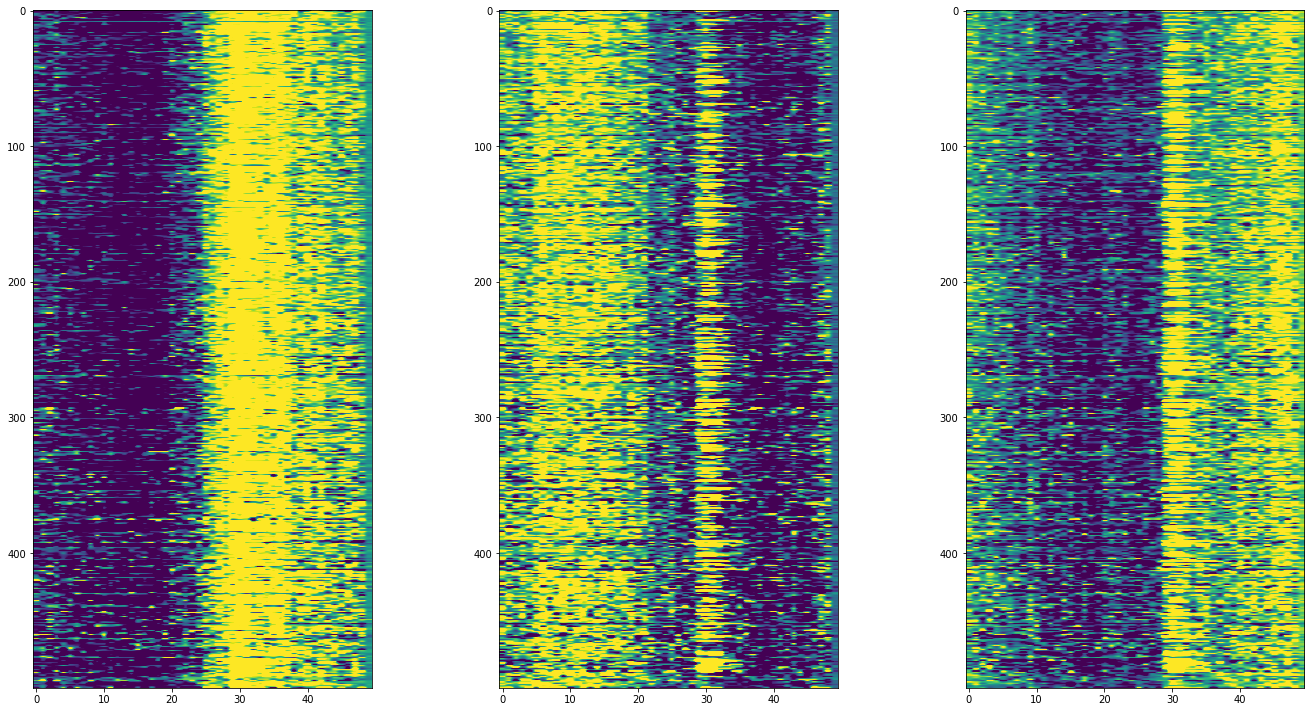

In [13]:
# ax_ap=0.1
# superclust_dict=best
# fig,axs=plt.subplots(1,3,figsize=(10,10))
# axs[0].imshow(superclust_dict['inc'], vmax=0.01,vmin=-0.01)
# axs[0].set_aspect(ax_ap)
# axs[1].imshow(superclust_dict['dec'],  vmax=0.01,vmin=-0.01)
# axs[1].set_aspect(ax_ap)
# axs[2].imshow(superclust_dict['flat'],  vmax=0.01,vmin=-0.01)
# axs[2].set_aspect(ax_ap)
# plt.tight_layout()

ax_ap=0.2
start=15
end=40
superclust_dict=five_sec
fig,axs=plt.subplots(1,3,figsize=(20,10))
axs[0].imshow(superclust_dict['inc'], vmax=0.01,vmin=-0.01)
axs[0].set_aspect(ax_ap)
axs[1].imshow(superclust_dict['dec'],  vmax=0.01,vmin=-0.01)
axs[1].set_aspect(ax_ap)
axs[2].imshow(superclust_dict['flat'],  vmax=0.01,vmin=-0.01)
axs[2].set_aspect(ax_ap)
# axs[3].imshow(superclust_dict['non'],  vmax=0.01,vmin=-0.01)
# axs[3].set_aspect(ax_ap)
plt.tight_layout()

In [14]:
# superclust_dict_z={}
# for behavior in best:
#     print(behavior)
#     signals_total_z=scipy.stats.zscore(best[behavior],axis=1)
#     superclust_dict_z[behavior]=signals_total_z
    
superclust_dict_z={}
for behavior in five_sec:
    print(behavior)
    signals_total_z=scipy.stats.zscore(five_sec[behavior][:,14:41],axis=1)
    superclust_dict_z[behavior]=signals_total_z

inc
dec
flat


In [15]:
superclust_dict_z['inc'].shape

(500, 27)

In [16]:
file_path=os.path.join(cluster_dir, 'individual_fly_superclusters_2bin.pkl')
with open(file_path, 'rb') as file:
        fly_superclust_dict = pickle.load(file)

In [17]:
fly_num=[226,227,228,234,239,240,241,242,249,250]
for fn in fly_num:
    behave_dic=fly_superclust_dict['flat']
    if fn in list(behave_dic.keys()):
        print(np.count_nonzero(~np.isnan(behave_dic[fn][...,0])))

3300
67178
17079
26372
2241
1167
5869
10698
38301
46647


In [18]:
fly_superclust_dict['inc'].keys()

dict_keys([226, 227, 228, 234, 239, 240, 241, 242, 249, 250])

In [19]:
num_vox=[]
for behave in fly_superclust_dict:
    for fly in fly_superclust_dict[behave]:
        count_vox=np.shape(fly_superclust_dict[behave][fly])[-2]
        num_vox.append(count_vox)
max_val=np.max(num_vox)
print(max_val)

1284


In [20]:
for behave in fly_superclust_dict:
    for fly in fly_superclust_dict[behave]:
        count_vox=np.shape(fly_superclust_dict[behave][fly])[-2]
        if count_vox<max_val:
            pad_val=max_val-count_vox
#             print(pad_val)
            matrix=fly_superclust_dict[behave][fly]
            padded_matrix = np.pad(matrix, ((0, 0), (0, pad_val),(0,0)),'constant', constant_values=np.nan)
            fly_superclust_dict[behave][fly]=padded_matrix 

In [21]:
intervals=np.asarray([[0,7],[12,19]])
downsampled_superclust_dict={}
clust_dict=superclust_dict
for behave in clust_dict:
    cluster_dict=np.asarray(clust_dict[behave])
    downsampled_superclust=[]
    for interval in intervals:
        start=interval[0]
        end=interval[1]
#         print(start-end)
        avg_time=np.mean(cluster_dict[:,start:end],axis=-1)
        downsampled_superclust.append(avg_time)
        start=end
    downsampled_superclust=np.asarray(downsampled_superclust).T
#     print(np.shape(downsampled_superclust))
    downsampled_superclust_dict[behave]=downsampled_superclust

In [22]:
%%time
anova_dict={}
for behave in fly_superclust_dict:
    anova_dict[behave]={}
    avg_clusts=downsampled_superclust_dict[behave]
    individual_clusts=fly_superclust_dict[behave]
    for i,super_clust in enumerate(avg_clusts):
        anova_dict[behave][i]=[]
        for v, tp in enumerate(super_clust):
            ind_clus=[]
            for fly in individual_clusts:
                ind_clus_nan=individual_clusts[fly][i,:,v]
#                 print(ind_clus_nan)
#                 if np.all(np.isnan(ind_clus_nan))==False:
                ind_clus=np.concatenate((ind_clus,ind_clus_nan))

            anova_dict[behave][i].append(np.asarray(ind_clus))
        anova_dict[behave][i]=np.asarray(anova_dict[behave][i])
#         print(np.shape(anova_dict[behave][i]))

CPU times: user 129 ms, sys: 47.1 ms, total: 176 ms
Wall time: 176 ms


In [23]:
dic=anova_dict
bs=np.asarray(list(dic.keys()))
combos=list(itertools.combinations(bs, 2))
print(combos)

[('inc', 'dec'), ('inc', 'flat'), ('dec', 'flat')]


In [24]:
def columnwise_mannwhitney(a, b):
    """
    Performs Mann-Whitney U test on each column separately
    a, b: arrays of shape (n_samples, n_features)
    Returns: arrays of statistics and p-values for each column
    """
    a = np.array(a)
    b = np.array(b)
    
    n_cols = a.shape[1]
    stats = []
    p_vals = []
    
    for col in range(n_cols):
        # Get data for this column
        a_col = a[:, col]
        b_col = b[:, col]
        
        # Remove NaNs
        a_clean = a_col[~np.isnan(a_col)]
        b_clean = b_col[~np.isnan(b_col)]
        
        if len(a_clean) < 1 or len(b_clean) < 1:
            stats.append(np.nan)
            p_vals.append(np.nan)
        else:
            try:
                stat, p_val = scipy.stats.mannwhitneyu(a_clean, b_clean)
                stats.append(stat)
                p_vals.append(p_val)
            except:
                stats.append(np.nan)
                p_vals.append(np.nan)
    
    return np.array(stats), np.array(p_vals)

In [25]:
pval_dict={}
for c in combos:
    b_1=c[0]
    b_2=c[1]
    new_key=f'{b_1}_vs_{b_2}'
    temp=[]
    for clust in range(500):
        a=np.moveaxis(anova_dict[b_1][clust],0,-1)
#         print(np.shape(a))
        b=np.moveaxis(anova_dict[b_2][clust],0,-1)
#         print(np.shape(b))
#         tstat,p_val=scipy.stats.ttest_ind(a,b,axis=-1,nan_policy='omit')
        stat,p_val=columnwise_mannwhitney(a,b)
#         print(p_val)
        temp.append(list(p_val))
    pval_dict[new_key]=temp

In [26]:
pval_dict.keys()

dict_keys(['inc_vs_dec', 'inc_vs_flat', 'dec_vs_flat'])

In [27]:
pval_correct_dict={}
for key in pval_dict:
    pval_flat=np.asarray(pval_dict[key]).flatten()
    rejected, p_corrected, alpha_sidak, alpha_bonf = multipletests(pval_flat, alpha=0.01, method='bonferroni')
    pval_correct=p_corrected.reshape(*np.shape(pval_dict[key]))
    pval_correct_dict[key]=pval_correct

In [28]:
k='inc_vs_dec'
# custom_labels = [''] * len(pval_correct_dict[k])  # Start with all empty strings
# custom_labels[281] = 'Here!!!'  # Set label at desired position

<AxesSubplot:>

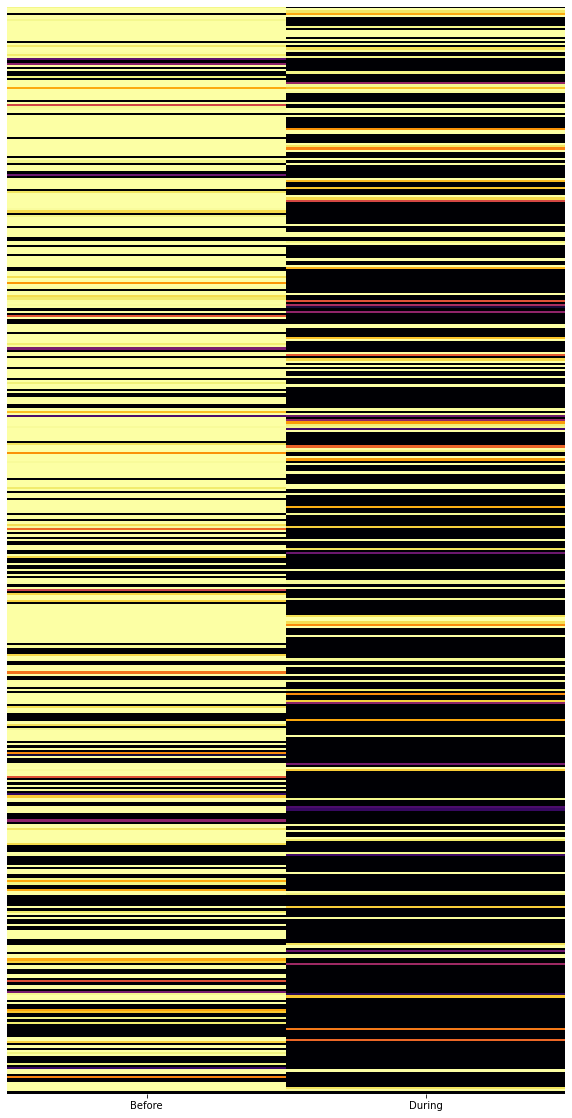

In [29]:
fig, ax = plt.subplots(figsize=(10, 20))  # Tall and narrow for 500x5
sns.heatmap(pval_correct_dict[k], 
            cmap='inferno_r', 
            ax=ax,yticklabels=False, cbar=False,
            xticklabels=['Before','During'],vmax=0.01)
# cbar = fig.colorbar(ax.collections[0], ax=ax)
# cbar.set_label('p-val', rotation=270, labelpad=20)
# cbar.outline.set_visible(False)
# ax.axhline(y=281,ls='--', color='g', lw=2)
# cbar.set_ticks([vmax, 0, vmin]) 
# ax.axhline(y=379, color='w', lw=2)
# plt.savefig(os.path.join(save_dir,f'p_vals_{b_1}_{b_2}.png'), dpi=300, bbox_inches='tight')

In [30]:
best_clus_dict={}
for ki in pval_correct_dict:
    print(ki)
    best_clus=[]
    for i,clus in enumerate(pval_correct_dict[ki]):
        if clus[0]<0.01:
            best_clus.append(i)
    print(best_clus)
    print(len(best_clus))
    best_clus_dict[ki]=best_clus

inc_vs_dec
[0, 1, 2, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 17, 18, 19, 20, 21, 22, 23, 24, 26, 27, 29, 32, 34, 35, 36, 37, 38, 39, 40, 41, 42, 44, 45, 46, 47, 48, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 61, 62, 63, 64, 65, 66, 67, 68, 70, 71, 73, 74, 75, 77, 79, 80, 81, 82, 83, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 96, 97, 98, 99, 100, 102, 103, 104, 105, 108, 109, 111, 112, 113, 115, 116, 117, 118, 119, 122, 123, 124, 125, 126, 127, 128, 129, 131, 132, 133, 134, 135, 136, 137, 138, 140, 142, 143, 146, 147, 148, 149, 151, 152, 153, 154, 155, 156, 157, 159, 160, 162, 163, 164, 165, 167, 168, 169, 170, 172, 173, 174, 175, 177, 180, 181, 182, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 218, 219, 220, 221, 222, 224, 225, 227, 228, 229, 230, 231, 232, 234, 235, 237, 238, 239, 240, 241, 243, 245, 248, 249, 252, 253, 256, 259, 261, 263, 264, 265, 267, 268, 270, 271, 272, 273, 2

In [31]:
comp='inc_vs_flat'
clusters_4_look=np.asarray(pval_correct_dict[comp][best_clus_dict[comp]])
# clusters_4_look=np.asarray(pval_correct_dict[comp][common_values])
# print(clusters_4_look.shape)
best_total=[best_clus_dict['inc_vs_dec'],best_clus_dict['dec_vs_flat'],best_clus_dict['inc_vs_flat']]
common_values=reduce(np.intersect1d, best_total)
print(np.shape(common_values))

(53,)


In [32]:
common_values

array([  7,  11,  17,  19,  27,  35,  41,  42,  44,  48,  50,  51,  54,
        58,  61,  66,  70,  79,  90, 108, 115, 117, 132, 138, 162, 163,
       169, 174, 187, 190, 203, 206, 207, 219, 248, 259, 281, 285, 289,
       304, 305, 307, 320, 335, 341, 365, 368, 408, 419, 433, 446, 455,
       497])

In [33]:
load_file = "/oak/stanford/groups/trc/data/Brezovec/2P_Imaging/anat_templates/20210817_luke_mean_highres.nii"
anat_high_res = np.asarray(nib.load(load_file).get_fdata().squeeze(), dtype='float32')
anat_high_res.shape
anat_uint=anat_high_res.astype('uint8')

In [34]:
atlas_path = "/oak/stanford/groups/trc/data/Brezovec/2P_Imaging/anat_templates/jfrc_2018_rois_improve_reorient_transformed_nearest_neighbor.nii"
atlas = np.asarray(nib.load(atlas_path).get_fdata().squeeze(), dtype='float32')
atlas = ants.from_numpy(atlas)
atlas.set_spacing((.76,.76,.76))
#atlas = ants.resample_image(atlas,(2,2,2),use_voxels=False)
atlas = ants.resample_image(atlas,(.5,.5,.5),use_voxels=False)
print(atlas.shape)
atlas = atlas.numpy()
atlas_int = atlas.astype('uint8')


(1256, 584, 363)


In [35]:
purp=np.asarray(['#9400D3','#FFFFFF'])[::-1]
grey=np.asarray(['#727272','#FFFFFF'])[::-1]
cmap_be = matplotlib.colors.LinearSegmentedColormap.from_list(
    'cmap', purp)

In [36]:
comp='dec_vs_flat'
giant_labels_anat=giant_total_labels.reshape(314,146,91)
nx,ny,nz=atlas.shape
ox,oy,oz=giant_labels_anat.shape
# scale_factors = (nx/ox, ny/oy, nz/oz)
scale_factors = (ox/nx, oy/ny, oz/nz)
# Resample using zoom with cubic interpolation (order=3)
anat_lowres = zoom(anat_high_res, scale_factors, order=3)
atlas_lowres = zoom(atlas_int, scale_factors, order=3)
labels_anat_sub_total=np.where(np.isin(giant_labels_anat,best_clus_dict[comp]),giant_labels_anat,np.nan)

In [37]:
print(anat_lowres.shape)
# atlas_int = anat_lowres.astype('uint8')

(314, 146, 91)


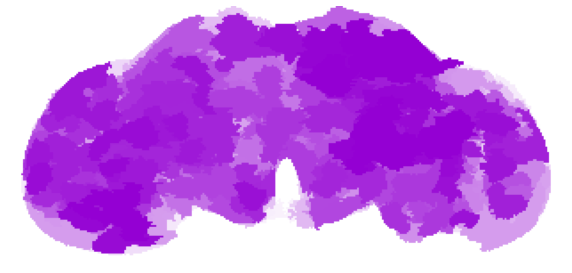

In [38]:
z=250
edges = cv2.Canny(np.max(atlas_lowres,axis=-1),1,1)
edges = binary_dilation(edges, iterations=1)
edges = scipy.ndimage.median_filter(edges,2)
edges_ = np.repeat(edges.astype('int')[:,:,np.newaxis],repeats=4,axis=-1) ### copy into rgba channels to make white
plt.figure(figsize=(10,10))
plt.imshow(np.max(anat_lowres, axis=-1).T,cmap='gray_r');
plt.imshow(np.nanmax(labels_anat_sub_total,axis=-1).T,cmap=cmap_be);
# plt.imshow(np.swapaxes(edges_,0,1)*10000);
plt.axis('off');
# # labels_anat_sub_total=np.where(np.isin(giant_labels_anat,top_indices[0]),giant_labels_anat,np.nan)   
# fig,ax=plt.subplots(figsize=(10,10))
# ax.imshow(np.nanmax(fixed.numpy(),axis=-1).T,cmap='bone')
# ax.imshow(np.nanmax(labels_anat_sub_total,axis=-1).T,cmap=cmap_be)
# ax.axis('off');
# plt.savefig(os.path.join(save_dir,f'p_vals_map_{comp}.png'), dpi=300, bbox_inches='tight')

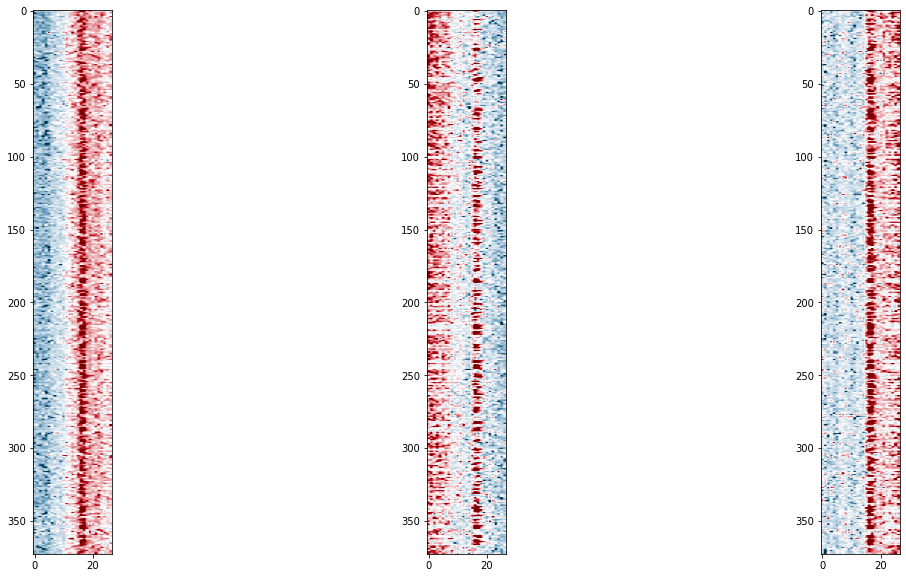

In [39]:
ax_ap=0.5
vmax=2
vmin=-2
comp='dec_vs_flat'
fig,ax=plt.subplots(1,3,figsize=(20,10))
b='inc'
ax[0].imshow(superclust_dict_z[b][best_clus_dict[comp],:],cmap=cmap_personal,vmax=vmax,vmin=vmin)
ax[0].set_aspect(ax_ap)
b='dec'
ax[1].imshow(superclust_dict_z[b][best_clus_dict[comp],:],cmap=cmap_personal,vmax=vmax,vmin=vmin)
ax[1].set_aspect(ax_ap)
b='flat'
ax[2].imshow(superclust_dict_z[b][best_clus_dict[comp],:],cmap=cmap_personal,vmax=vmax,vmin=vmin)
ax[2].set_aspect(ax_ap)

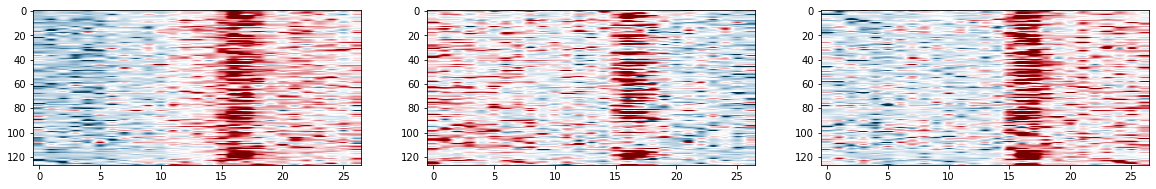

In [40]:
ax_ap=0.1
vmax=2
vmin=-2
not_in=~np.isin(np.arange(500),best_clus_dict[comp])
fig,ax=plt.subplots(1,3,figsize=(20,10))
b='inc'
ax[0].imshow(superclust_dict_z[b][not_in,:],cmap=cmap_personal,vmax=vmax,vmin=vmin)
ax[0].set_aspect(ax_ap)
b='dec'
ax[1].imshow(superclust_dict_z[b][not_in,:],cmap=cmap_personal,vmax=vmax,vmin=vmin)
ax[1].set_aspect(ax_ap)
b='flat'
ax[2].imshow(superclust_dict_z[b][not_in,:],cmap=cmap_personal,vmax=vmax,vmin=vmin)
ax[2].set_aspect(ax_ap)

In [41]:
def which_behave(labels,cluster,superclust_dict):
    clus_in=np.where(labels==cluster)[0]
    remains=np.remainder(clus_in,3)
    which=np.full(*np.shape(remains),str)

    for i in range(len(superclust_dict)):
        if i==1:
            behave='dec'
        elif i==2:
            behave='flat'
        else:
            behave='inc'
        which[np.where(remains==i)]=behave
    return clus_in,which

In [42]:
behavior_colors={
    'inc': '#9400D3',
    'dec': '#727272',
    'flat': '#000000'
}

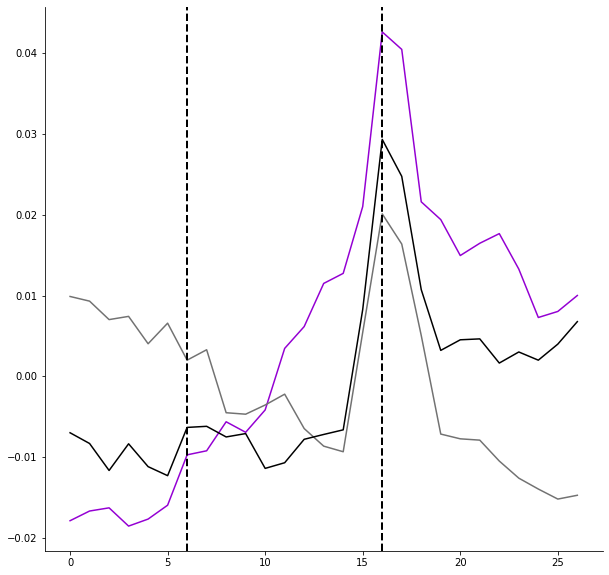

In [43]:
fig,axs=plt.subplots(figsize=(10,10))
rois=best_clus_dict[comp]

plot_dict=superclust_dict
for behave in plot_dict:
    avg_clus=np.mean(plot_dict[behave][rois,14:41],axis=0)
    axs.plot(avg_clus,color=behavior_colors[behave], label=behave)
x1=6;x2=16
axs.axvline(x=x1, ymin=0, ymax=1, ls='--', color='k', lw=2)
axs.axvline(x=x2, ymin=0, ymax=1, ls='--', color='k', lw=2)
axs.spines['top'].set_visible(False)
axs.spines['right'].set_visible(False)
#     axs.spines['bottom'].set_visible(False)
#     axs.spines['left'].set_visible(False)
# plt.savefig(os.path.join(save_dir,f'{comp}_mostsig_cluster_time_trace.png'), dpi=300, bbox_inches='tight')

In [44]:
data=anova_dict
rows = []
for category in data.keys():
    for cluster_num in data[category].keys():
#         if int(cluster_num) <= 100:
        array_2d =data[category][cluster_num]

        # For dimension 0
        for val in array_2d[0]:
            rows.append({
                'cluster': cluster_num,
                'category': category,
                'time': 'before',
                'dff': val
            })

        # For dimension 1
        for val in array_2d[1]:
            rows.append({
                'cluster': cluster_num,
                'category': category,
                'time': 'during',
                'dff': val
            })

df = pd.DataFrame(rows)

In [45]:
df_filtered = df[df['cluster'].isin(best_clus_dict[comp])]
df_before = df_filtered[df_filtered['time'] == 'before']
df_during = df_filtered[df_filtered['time'] == 'during']

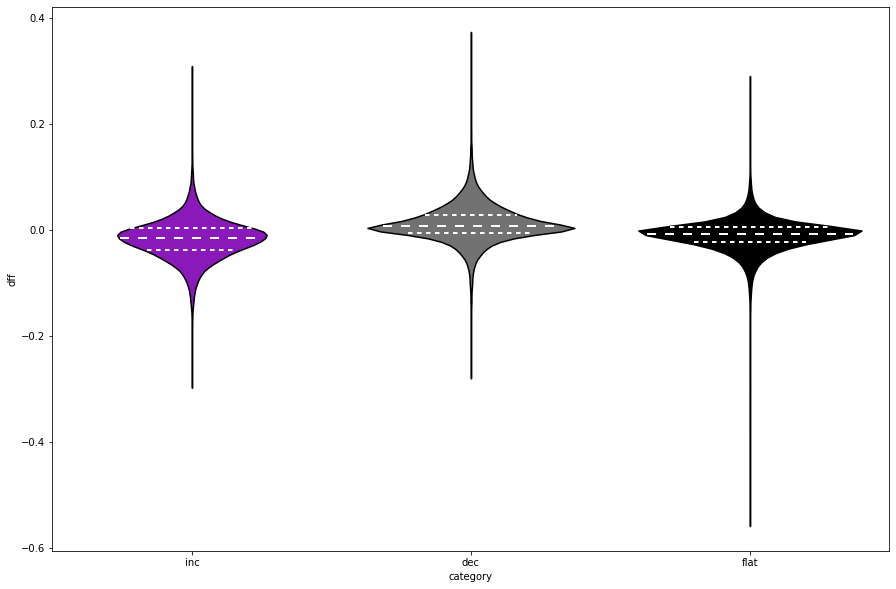

In [46]:
fig, ax = plt.subplots(figsize=(15, 10))
sns.violinplot(
    data=df_before,
    x='category',
    y='dff',
    palette=behavior_colors,
    ax=ax, 
    inner="quart"
)

for artist in ax.get_children():
    if isinstance(artist, plt.Line2D):
        # These are the quartile lines inside the violins
        artist.set_color('white')
        artist.set_linewidth(2)

# plt.savefig(os.path.join(save_dir,f'{comp}_mostsig_cluster_violin.png'), dpi=300, bbox_inches='tight')

In [47]:
def plot_cluster_traces(clusters_4_look,clust_dict=None, z=False, secondary=None):
    fig_shape=int(np.ceil(np.sqrt(len(clusters_4_look))))
    # print(clusters_4_look.shape)
    # print(fig_shape)
    if len(clusters_4_look)>1:
        if len(clusters_4_look)==2:
            fig,axs=plt.subplots(1,2,figsize=(10,5))
        else:
            fig,axs=plt.subplots(fig_shape,fig_shape,figsize=(10,10))
            axs=axs.flatten()
        for behave in clust_dict:
            for ind in range(clusters_4_look.size):
                clus=clusters_4_look[ind]
        #         print(clus)
                if clust_dict[behave][clus,:].shape[0]>30:
                    start=15;end=40
                else:
                    start=0;end=-1
                axs[ind].plot(clust_dict[behave][clus,start:end],color=behavior_colors[behave], label=behave)
                if z:
                    axs[ind].set_ylim(-2,3.5)
                else:
                    axs[ind].set_ylim(-0.05,0.1)
                axs[ind].set_xticks([])
                axs[ind].set_yticks([])
                axs[ind].set_title(clus,fontsize=10)
                x1=6;x2=16
                axs[ind].axvline(x=x1, ymin=0, ymax=1, ls='--', color='k', lw=2)
                axs[ind].axvline(x=x2, ymin=0, ymax=1, ls='--', color='k', lw=2)
                axs[ind].spines['top'].set_visible(False)
                axs[ind].spines['right'].set_visible(False)
                axs[ind].spines['bottom'].set_visible(False)
                axs[ind].spines['left'].set_visible(False)
                if secondary is not None:
                    axs[ind].set_xlabel(secondary[ind])
        plt.tight_layout() 
    else:
        fig,axs=plt.subplots(figsize=(10,10))
        for behave in clust_dict:
            clus=clusters_4_look[0]
    #         print(clust_dict[behave][clus,:].shape)
            if clust_dict[behave][clus,:].shape[0]>30:
                start=15;end=40
            else:
                start=0;end=-1
            axs.plot(clust_dict[behave][clus,start:end],color=colors[behave], label=behave)
            if z:
                axs.set_ylim(-2,3.5)
            else:
                axs.set_ylim(-0.05,0.1)
            axs.set_xticks([])
    #         axs.set_yticks([])
            axs.set_title(clus,fontsize=10)
            x1=6;x2=16
            axs.axvline(x=x1, ymin=0, ymax=1, ls='--', color='k', lw=2)
            axs.axvline(x=x2, ymin=0, ymax=1, ls='--', color='k', lw=2)
            axs.spines['top'].set_visible(False)
            axs.spines['right'].set_visible(False)
            axs.spines['bottom'].set_visible(False)
            axs.spines['left'].set_visible(False)
            if secondary is not None:
                    axs.set_xlabel(secondary[ind])
    
    giant_labels_anat=giant_total_labels.reshape(314,146,91)
    labels_anat_sub_total=np.where(np.isin(giant_labels_anat,clusters_4_look),giant_labels_anat,np.nan)
    # labels_anat_sub_total=np.where(np.isin(giant_labels_anat,top_indices[0]),giant_labels_anat,np.nan)   
    fig,ax=plt.subplots(figsize=(10,10))
    ax.imshow(np.nanmax(fixed.numpy(),axis=-1).T,cmap='Greys_r')
    ax.imshow(np.nanmax(labels_anat_sub_total,axis=-1).T,cmap='spring')
    ax.axis('off');


In [48]:
giant_superclust=[]
for i in range(superclust_dict_z['inc'].shape[0]):
    clust_behave=np.vstack((superclust_dict_z['inc'][i,:],superclust_dict_z['dec'][i,:],superclust_dict_z['flat'][i,:]))
    giant_superclust.append(clust_behave)
giant_superclust=np.vstack(giant_superclust)
print(giant_superclust.shape)

(1500, 27)


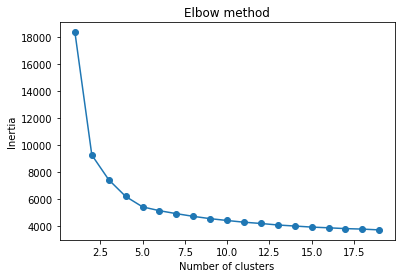

In [49]:
data=gaussian_filter1d(giant_superclust,sigma=1)
# data=giant_superclust

inertias = []
ks = 20

for i in range(1,ks):
    kmeans = sklearn.cluster.KMeans(n_clusters=i)
    kmeans.fit(data)
    inertias.append(kmeans.inertia_)

plt.plot(range(1,ks), inertias, marker='o')
plt.title('Elbow method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
# plt.savefig(os.path.join(save_dir,f'k_elbow_smooth.png'), dpi=300, bbox_inches='tight')
plt.show()

In [50]:
n_clusters=6
kmeans = sklearn.cluster.KMeans(n_clusters=n_clusters)
kmeans.fit(data)
np.shape(kmeans.labels_)

(1500,)

In [51]:
labels=kmeans.labels_
sort_array=np.argsort(labels)
k_clustered=data[sort_array]

In [52]:
rainbow_color=np.asarray(['#EF476F', '#F78C6B', '#FFD166', '#06D6A0','#118AB2','#6A4C93', '#6d0d25']) 
rainbow_color=rainbow_color[:n_clusters]
# cmap_rainbow = matplotlib.colors.LinearSegmentedColormap.from_list(
#     'cmap', rainbow_color)
cmap_rainbow = matplotlib.colors.ListedColormap(rainbow_color)

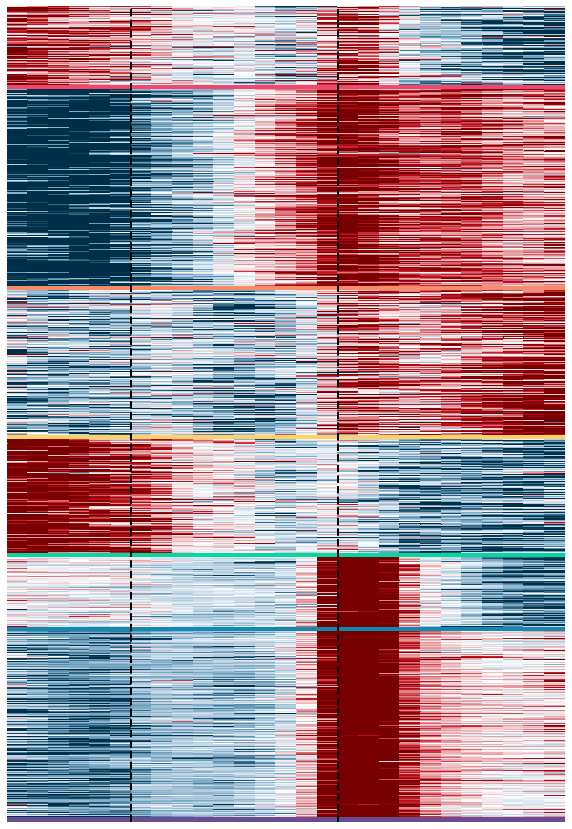

In [53]:
n_clusters=6
to_plot=k_clustered
color_map=rainbow_color
clustered=np.unique(labels)
vmax=1
vmin=-1
fig,axs=plt.subplots(figsize=(10,15))
sns.heatmap(to_plot,yticklabels=[],xticklabels=[],
            cmap=cmap_personal, cbar=False, ax=axs, center=0,vmax=vmax,vmin=vmin)
superclust_size=np.shape(to_plot)[0]
total=0
axs.axhline(y=1500, color=color_map[-1], lw=10)
for cluss in clustered:
    clus_size=np.shape(labels[labels==cluss])[0]
    total+=clus_size
    if total<superclust_size:
        axs.axhline(y=(total), color=color_map[cluss], lw=4)
x1=6;x2=16
axs.axvline(x=x1, ymin=0, ymax=1, ls='--', color='k', lw=2)
axs.axvline(x=x2, ymin=0, ymax=1, ls='--', color='k', lw=2)
# plt.savefig(os.path.join(save_dir,f'k_{n_clusters}clusters_smooth.png'), dpi=300, bbox_inches='tight')

In [54]:
types=np.zeros((superclust_dict_z['inc'].shape[0], len(superclust_dict_z)))
for clus in clustered:
    clus_in=np.where(labels==clus)[0]
    remains=np.remainder(clus_in,3)
    which=np.full(*np.shape(remains),str)
    
    for i in range(len(superclust_dict_z)):
        if i==1:
            behave='dec'
        elif i==2:
            behave='flat'
        else:
            behave='inc'
        which[np.where(remains==i)]=behave
    for i,el in enumerate(clus_in):
        clus_name=int(np.ceil(el/3))-1
        behave=which[i]
        if behave=='flat':
            types[clus_name,0]=clus
        elif behave=='inc':
            types[clus_name,1]=clus
        else:
            types[clus_name,2]=clus

<AxesSubplot:>

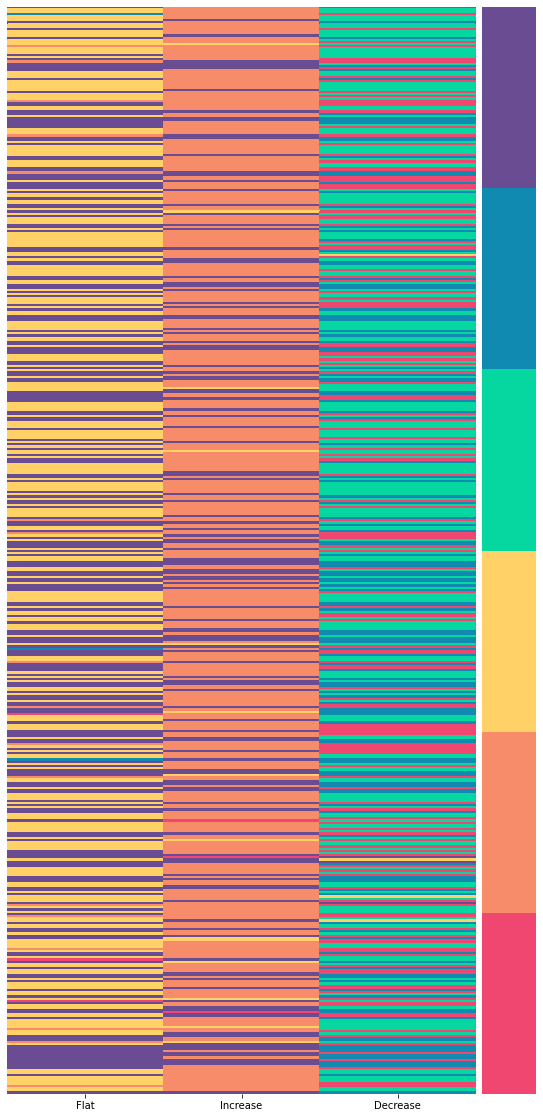

In [55]:
fig, ax = plt.subplots(figsize=(10, 20))  # Tall and narrow for 500x5
# custom_ticks=np.arange(1,(n_clusters+1))
# sns.set(font_scale=1)
sns.heatmap(types, 
            cmap=cmap_rainbow, 
            ax=ax,yticklabels=False, cbar=True,
            xticklabels=['Flat','Increase','Decrease'], 
            cbar_kws={'ticks': [],"pad": 0.01})

# plt.savefig(os.path.join(save_dir,f'k_{n_clusters}types_smooth.png'), dpi=300, bbox_inches='tight')

In [56]:
labels

array([5, 4, 5, ..., 1, 4, 5], dtype=int32)

In [57]:
stat_sig=best_clus_dict['inc_vs_flat']

In [58]:
sig_best_clus={}
for cluster in range(n_clusters):
    print(cluster)
    sig_best_clus[cluster]=[]
    clusters_4_look=np.where(labels==cluster)[0]
    clusters_4_look=np.ceil(clusters_4_look/3).astype(int)
#     print(np.shape(clusters_4_look))
    uniques=np.unique(clusters_4_look)-1
    uniques[uniques==8]=uniques[-1]
#     print(np.shape(uniques))
    for clus in stat_sig:
        if clus in uniques:
            sig_best_clus[cluster].append(clus)
    sig_best_clus[cluster]=np.asarray(sig_best_clus[cluster])

0
1
2
3
4
5


In [59]:
best_total=[sig_best_clus[5], sig_best_clus[3]]
common_values=reduce(np.intersect1d, best_total)

In [60]:
common_values

array([ 54,  70, 163, 259, 289, 307, 335, 365])

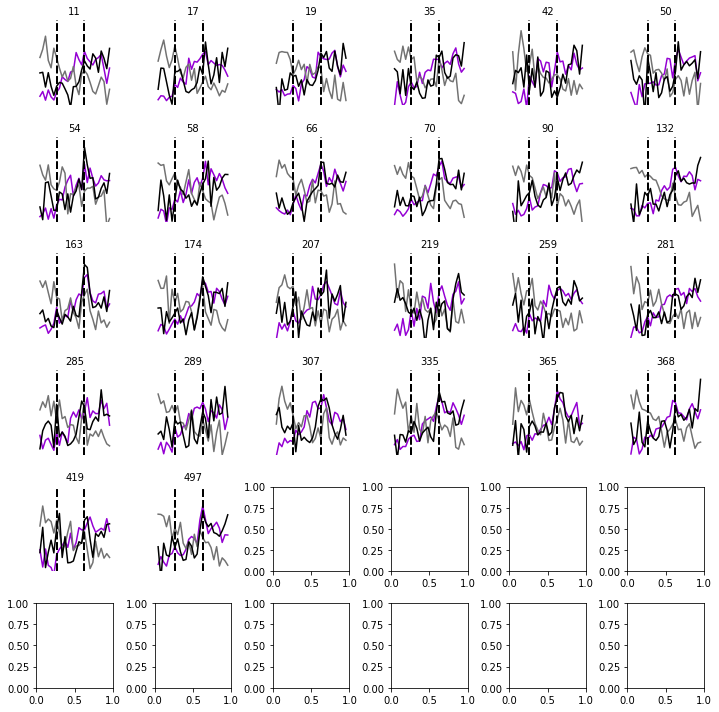

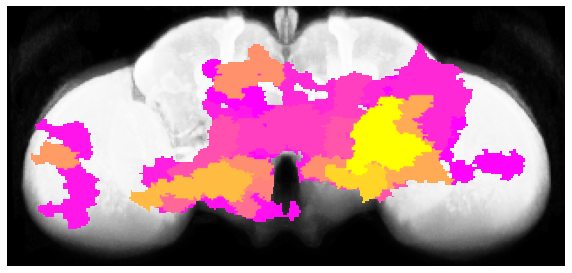

In [61]:
cluster=3
plot_cluster_traces(sig_best_clus[cluster],superclust_dict_z, z=True)

In [62]:
# ##find the clusters that are the same in each kmeans cluster
# cluster=0
# clusters_4_look=np.where(labels==cluster)[0]
# clusters_4_look=np.ceil(clusters_4_look/3).astype(int)
# print(np.shape(clusters_4_look))
# unique_values,counts= np.unique(clusters_4_look, return_counts=True)
# print(np.shape(unique_values))
# # Find values that appear more than once
# repeating_values = unique_values[counts > 2]
# repeat_num = counts[counts > 2]
# print(repeating_values)
# print(repeat_num)
# clus_in=np.where(labels==cluster)[0]
# remains=np.remainder(clus_in,3)
# which=np.full(*np.shape(remains),str)

# for i in range(len(superclust_dict_z)):
#     if i==1:
#         behave='dec'
#     elif i==2:
#         behave='flat'
#     else:
#         behave='inc'
#     which[np.where(remains==i)]=behave
# for clu in repeating_values:
#     all_indices = np.where(clusters_4_look == clu)[0]
#     trial_type=which[all_indices]
#     print(f"Value {clu}: {trial_type}")

In [63]:
# plot_cluster_traces(repeating_values,superclust_dict_z, z=True)

In [64]:
cluster=2
clusters_4_look=np.where(labels==cluster)[0]
clusters_4_look=np.ceil(clusters_4_look/3).astype(int)
print(np.shape(clusters_4_look))
uniques=np.unique(clusters_4_look)-1
uniques[uniques==8]=uniques[-1]
print(np.shape(uniques))
# uniques
# plot_cluster_traces(uniques,superclust_dict_z, z=True)

(274,)
(263,)


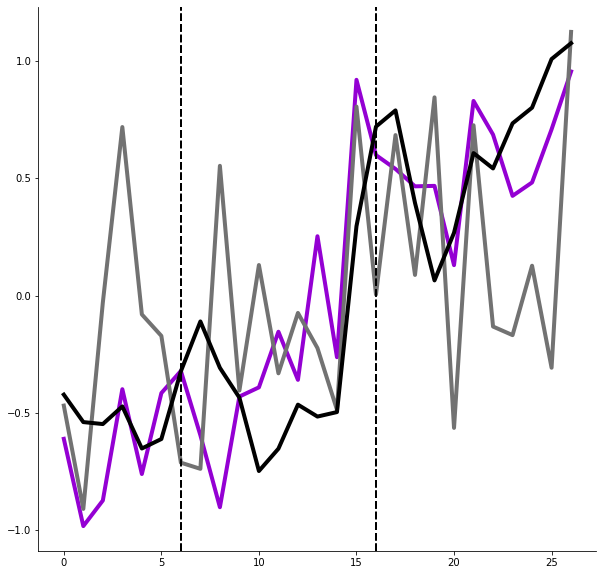

In [65]:
fig,axs=plt.subplots(figsize=(10,10))
rois=uniques
clus_in,which=which_behave(labels,cluster,superclust_dict)
for behave in superclust_dict_z:
    behave_clusts=clus_in[which==behave]
    real_clus=np.floor(behave_clusts/3).astype(int)
    if real_clus is not []:
        temp=np.mean(superclust_dict_z[behave][real_clus],axis=0)
        axs.plot(temp,color=behavior_colors[behave], label=behave, lw=4)
        x1=6;x2=16
        axs.axvline(x=x1, ymin=0, ymax=1, ls='--', color='k', lw=2)
        axs.axvline(x=x2, ymin=0, ymax=1, ls='--', color='k', lw=2)
        axs.spines['top'].set_visible(False)
        axs.spines['right'].set_visible(False)
#     axs.spines['bottom'].set_visible(False)
#     axs.spines['left'].set_visible(False)
# plt.savefig(os.path.join(save_dir,f'k_{cluster+1}cluster_time_trace.png'), dpi=300, bbox_inches='tight')

In [66]:
pval_correct_dict.keys()

dict_keys(['inc_vs_dec', 'inc_vs_flat', 'dec_vs_flat'])

In [67]:
same_before=[]
same_during=[]
same=[]
pvals=pval_correct_dict
for i in range(np.shape(list(pvals.values()))[1]):
    keys=np.asarray(list(pvals.keys()))
    ar_1=pvals[keys[0]][i]
    ar_2=pvals[keys[1]][i]
    ar_3=pvals[keys[2]][i]
#     if ar_1[0]>0.01 and ar_2[0]>0.01 and ar_3[0]>0.01:
#         same_before.append(i)
#     elif ar_1[1]>0.01 and ar_2[1]>0.01 and ar_3[1]>0.01:
#         same_during.append(i)
    if ar_1[0]>0.01 and ar_2[0]>0.01 and ar_3[0]>0.01 and ar_1[1]>0.01 and ar_2[1]>0.01 and ar_3[1]>0.01:
        same.append(i)
same_before=np.asarray(same_before)
same_during=np.asarray(same_during)
same=np.asarray(same)

In [68]:
same.shape

(89,)

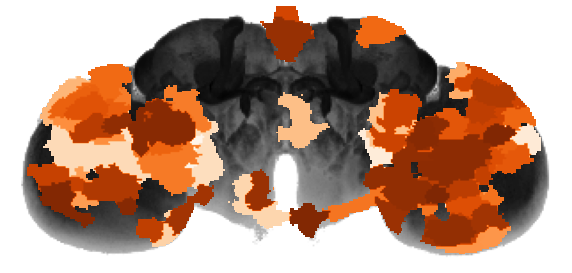

In [69]:
giant_labels_anat=giant_total_labels.reshape(314,146,91)
labels_anat_sub_total=np.where(np.isin(giant_labels_anat,same),giant_labels_anat,np.nan)
# labels_anat_sub_total=np.where(np.isin(giant_labels_anat,top_indices[0]),giant_labels_anat,np.nan)   
plt.figure(figsize=(10,10))
plt.imshow(np.max(anat_lowres, axis=-1).T,cmap='gray_r');
plt.imshow(np.nanmax(labels_anat_sub_total,axis=-1).T,cmap='Oranges');
# plt.imshow(np.swapaxes(edges_,0,1)*10000);
plt.axis('off');
# plt.savefig(os.path.join(save_dir,f'p_vals_map_nonsig.png'), dpi=300, bbox_inches='tight')

In [105]:
same

array([ 43,  49,  60,  69,  76,  78,  84, 106, 107, 110, 114, 121, 130,
       141, 144, 150, 161, 171, 176, 179, 184, 200, 217, 223, 246, 247,
       254, 258, 260, 262, 269, 274, 293, 296, 297, 301, 302, 308, 309,
       313, 325, 327, 331, 338, 340, 342, 346, 347, 355, 357, 359, 366,
       367, 371, 373, 375, 391, 392, 393, 396, 400, 405, 409, 410, 412,
       413, 415, 418, 420, 429, 430, 444, 447, 449, 457, 459, 463, 468,
       472, 473, 477, 479, 483, 485, 487, 491, 493, 494, 499])

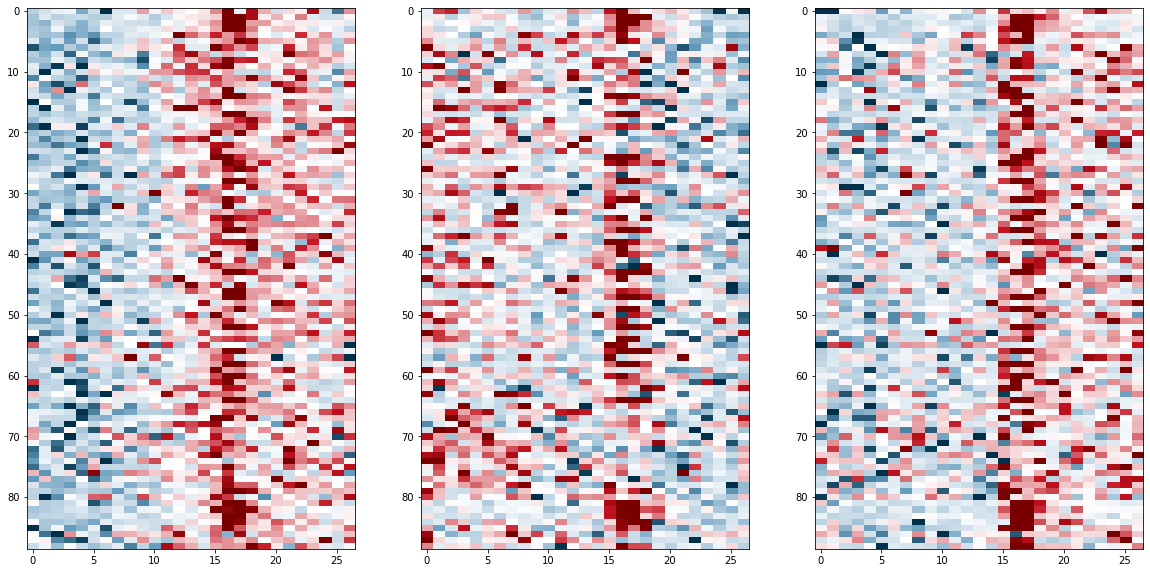

In [70]:
ax_ap=0.5
vmax=2
vmin=-2
# not_in=~np.isin(np.arange(500),rois)
fig,ax=plt.subplots(1,3,figsize=(20,10))
b='inc'
ax[0].imshow(superclust_dict_z[b][same,:],cmap=cmap_personal,vmax=vmax,vmin=vmin)
ax[0].set_aspect(ax_ap)
b='dec'
ax[1].imshow(superclust_dict_z[b][same,:],cmap=cmap_personal,vmax=vmax,vmin=vmin)
ax[1].set_aspect(ax_ap)
b='flat'
ax[2].imshow(superclust_dict_z[b][same,:],cmap=cmap_personal,vmax=vmax,vmin=vmin)
ax[2].set_aspect(ax_ap)

In [71]:
same

array([ 43,  49,  60,  69,  76,  78,  84, 106, 107, 110, 114, 121, 130,
       141, 144, 150, 161, 171, 176, 179, 184, 200, 217, 223, 246, 247,
       254, 258, 260, 262, 269, 274, 293, 296, 297, 301, 302, 308, 309,
       313, 325, 327, 331, 338, 340, 342, 346, 347, 355, 357, 359, 366,
       367, 371, 373, 375, 391, 392, 393, 396, 400, 405, 409, 410, 412,
       413, 415, 418, 420, 429, 430, 444, 447, 449, 457, 459, 463, 468,
       472, 473, 477, 479, 483, 485, 487, 491, 493, 494, 499])

In [72]:
def explode_plot(brain,vmax,explosion_rois,roi_masks,roi_contours,tp=None,cmap='seismic'):
    input_canvas = np.ones((500,500,3)) #+.5 #.5 for diverging
    if tp==None:
        data_to_plot = brain[:,:,::-1]
    else:
        data_to_plot = brain[tp][:,:,::-1]
    vmax =vmax #this was 0.5 for STA <------------
    explosion_map = brainsss.place_roi_groups_on_canvas(explosion_rois,
                                                        roi_masks,
                                                        roi_contours,
                                                        data_to_plot,
                                                        input_canvas,
                                                        vmax=vmax,
                                                        cmap=cmap, diverging=True)#'hot')
    return explosion_map

In [73]:
full_res_superclust={}
superclust=superclust_dict_z
n_clusters=500
for behave in superclust:
    cluster_brain=superclust[behave]
    brain=cluster_brain.T
    cluster_labels=giant_total_labels.T
    n_tp = brain.shape[0]
    n_clusters = brain.shape[1]
    brain_dims=[314,146,91]

    colored_by_betas = np.zeros((n_tp, brain_dims[0]*brain_dims[1]*brain_dims[2]))
    colored_by_betas = brain[:, cluster_labels]  # Shape: (n_tp, n_voxels)
    colored_by_betas = colored_by_betas.reshape(n_tp, brain_dims[0], brain_dims[1], brain_dims[2])
    #     for cluster_num in range(n_clusters):
    #         cluster_mask = cluster_labels==cluster_num
    # #         print(np.shape(cluster_mask))
    #         colored_by_betas[:,cluster_mask] = brain[:,cluster_num,np.newaxis]
    colored_by_betas = colored_by_betas.reshape(n_tp,brain_dims[0],brain_dims[1],brain_dims[2])
    full_res_superclust[behave]=np.asarray(colored_by_betas)

In [74]:
full_res_superclust.keys()

dict_keys(['inc', 'dec', 'flat'])

In [75]:
giant_labels_anat=giant_total_labels.reshape(314,146,91)

In [76]:
roi_atlas = brainsss.load_roi_atlas()
explosion_rois = brainsss.load_explosion_groups()
all_rois = brainsss.unnest_roi_groups(explosion_rois)
roi_masks = brainsss.make_single_roi_masks(all_rois, roi_atlas)
roi_contours = brainsss.make_single_roi_contours(roi_masks, roi_atlas)

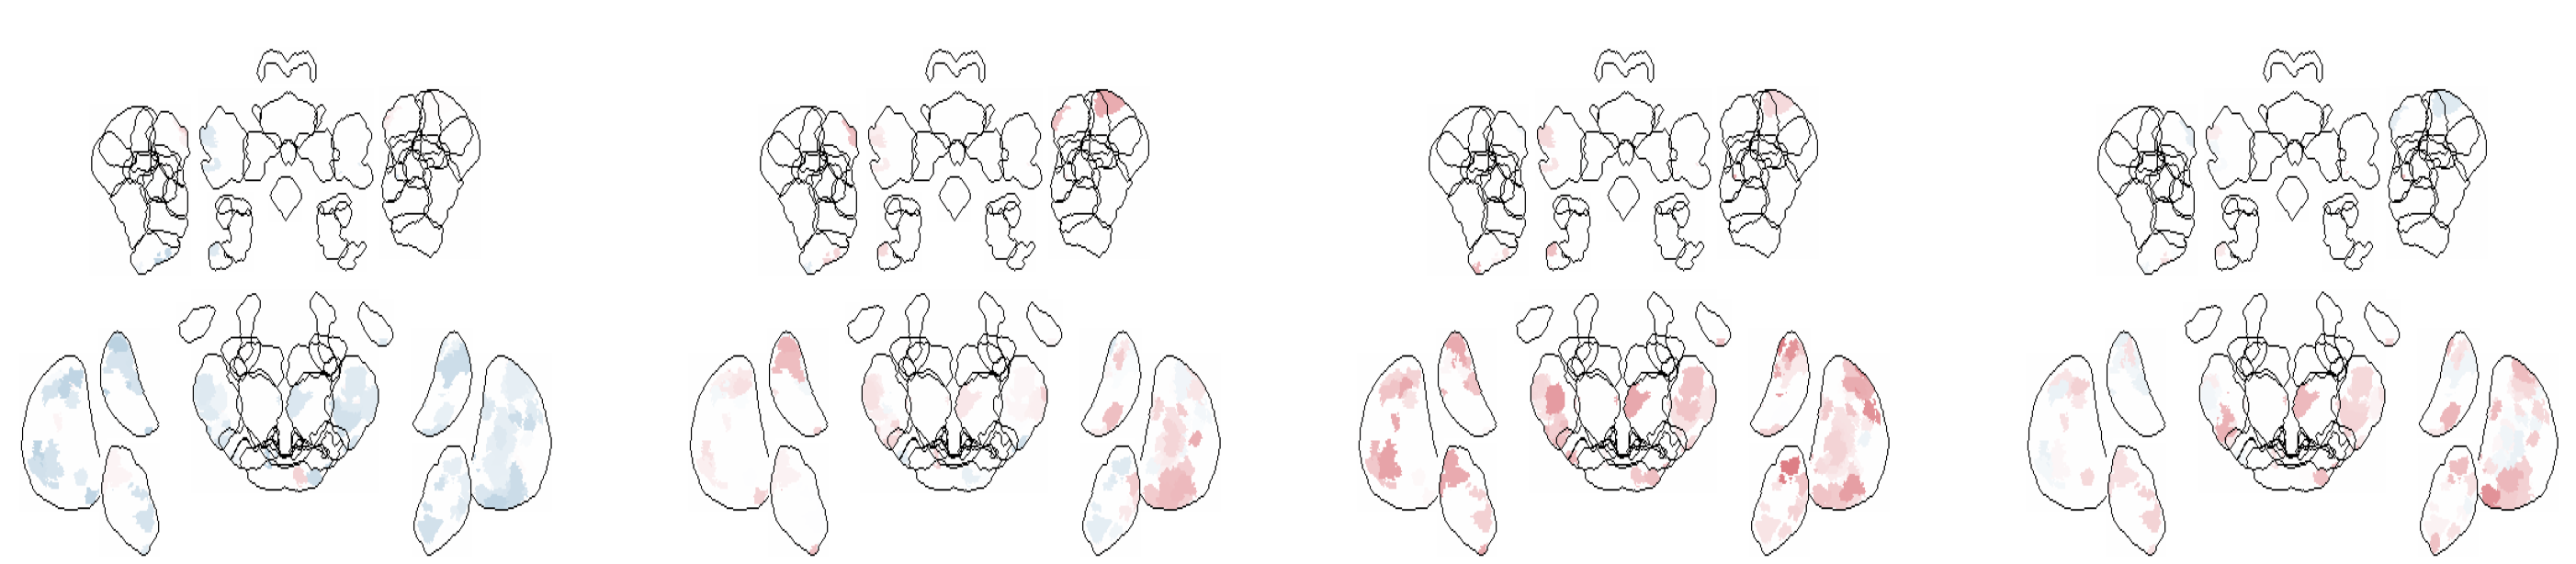

In [77]:
b='inc'
brain=full_res_superclust[b]
roi_of_interest=same
ax_as=1.5
# range_of_interest=np.arange(13,18).astype(int)
range_of_interest=np.asarray([3,14,15,23])
fig,axs=plt.subplots(1,4,figsize=(50,50))
for i,tp in enumerate(range_of_interest):
    masked_nonan=np.where(np.isin(giant_labels_anat,roi_of_interest),brain, np.nan)
    masked_nonan=np.nan_to_num(masked_nonan)
    vmax=5
    temp=explode_plot(masked_nonan,vmax,explosion_rois,roi_masks,roi_contours,tp,cmap=cmap_personal)
    axs[i].imshow(temp[170:,:]) #this was made with cmap=hot
    axs[i].axis('off')
#     axs[i].set_title(f'{tp}',fontsize=50)
    axs[i].set_aspect(ax_as)
# plt.savefig(os.path.join(save_dir,f'explosion_{b}_nonsig.png'), dpi=300, bbox_inches='tight')

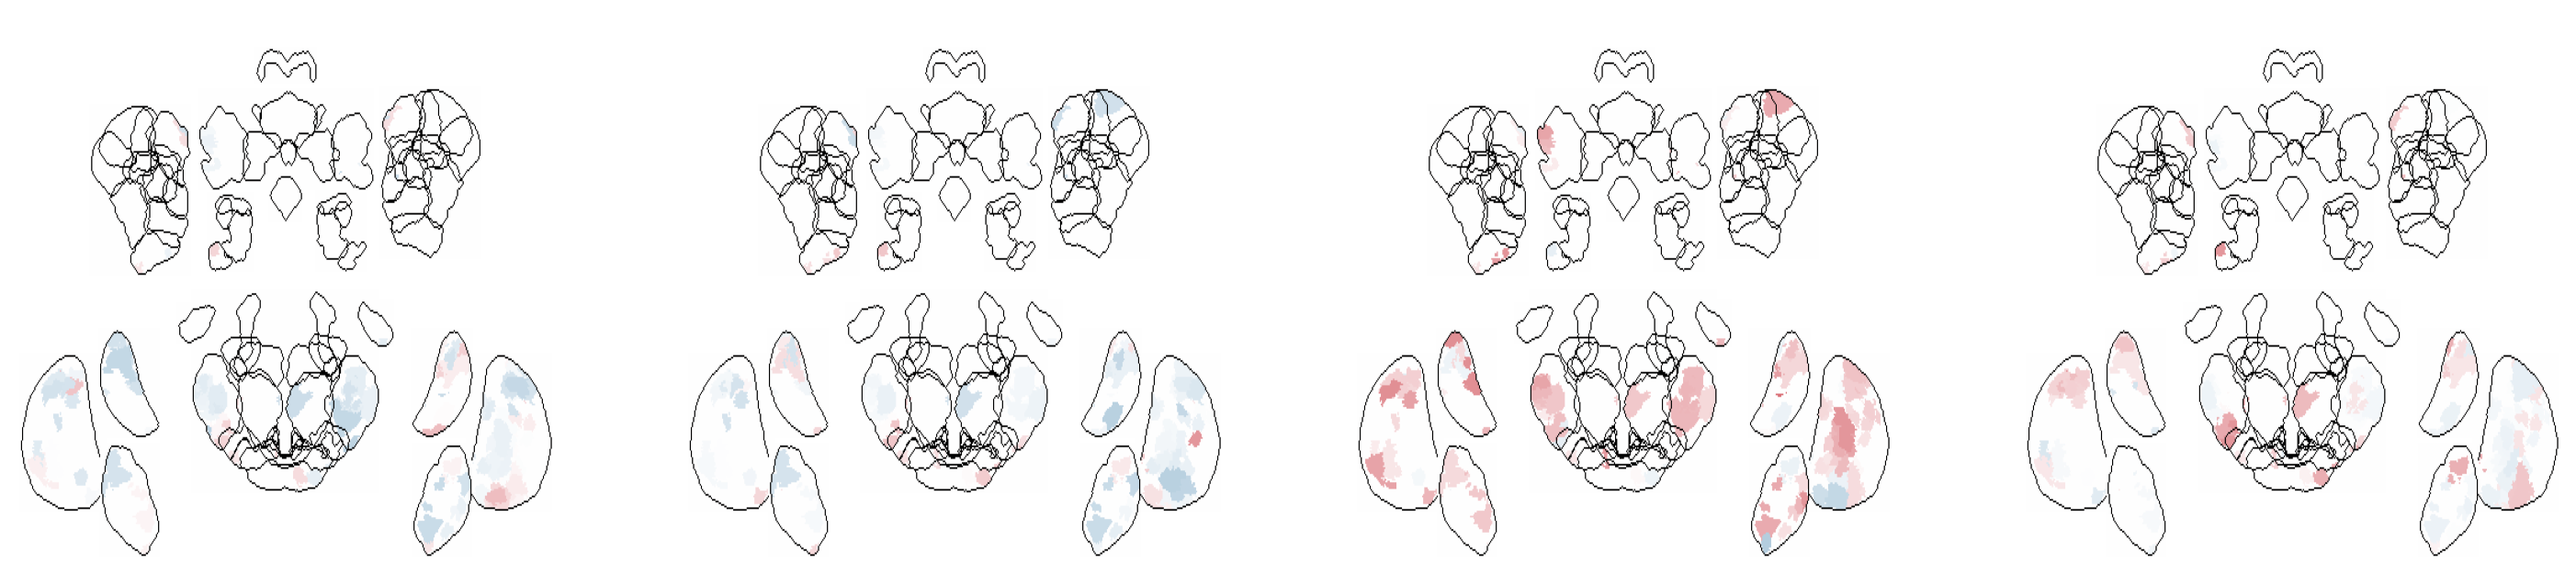

In [78]:
b='flat'
brain=full_res_superclust[b]
fig,axs=plt.subplots(1,4,figsize=(50,50))
for i,tp in enumerate(range_of_interest):
    masked_nonan=np.where(np.isin(giant_labels_anat,roi_of_interest),brain, np.nan)
    masked_nonan=np.nan_to_num(masked_nonan)
    vmax=5
    temp=explode_plot(masked_nonan,vmax,explosion_rois,roi_masks,roi_contours,tp,cmap=cmap_personal)
    axs[i].imshow(temp[170:,:]) #this was made with cmap=hot
    axs[i].axis('off')
#     axs[i].set_title(f'{tp}',fontsize=50)
    axs[i].set_aspect(ax_as)
# plt.savefig(os.path.join(save_dir,f'explosion_{b}_nonsig.png'), dpi=300, bbox_inches='tight')

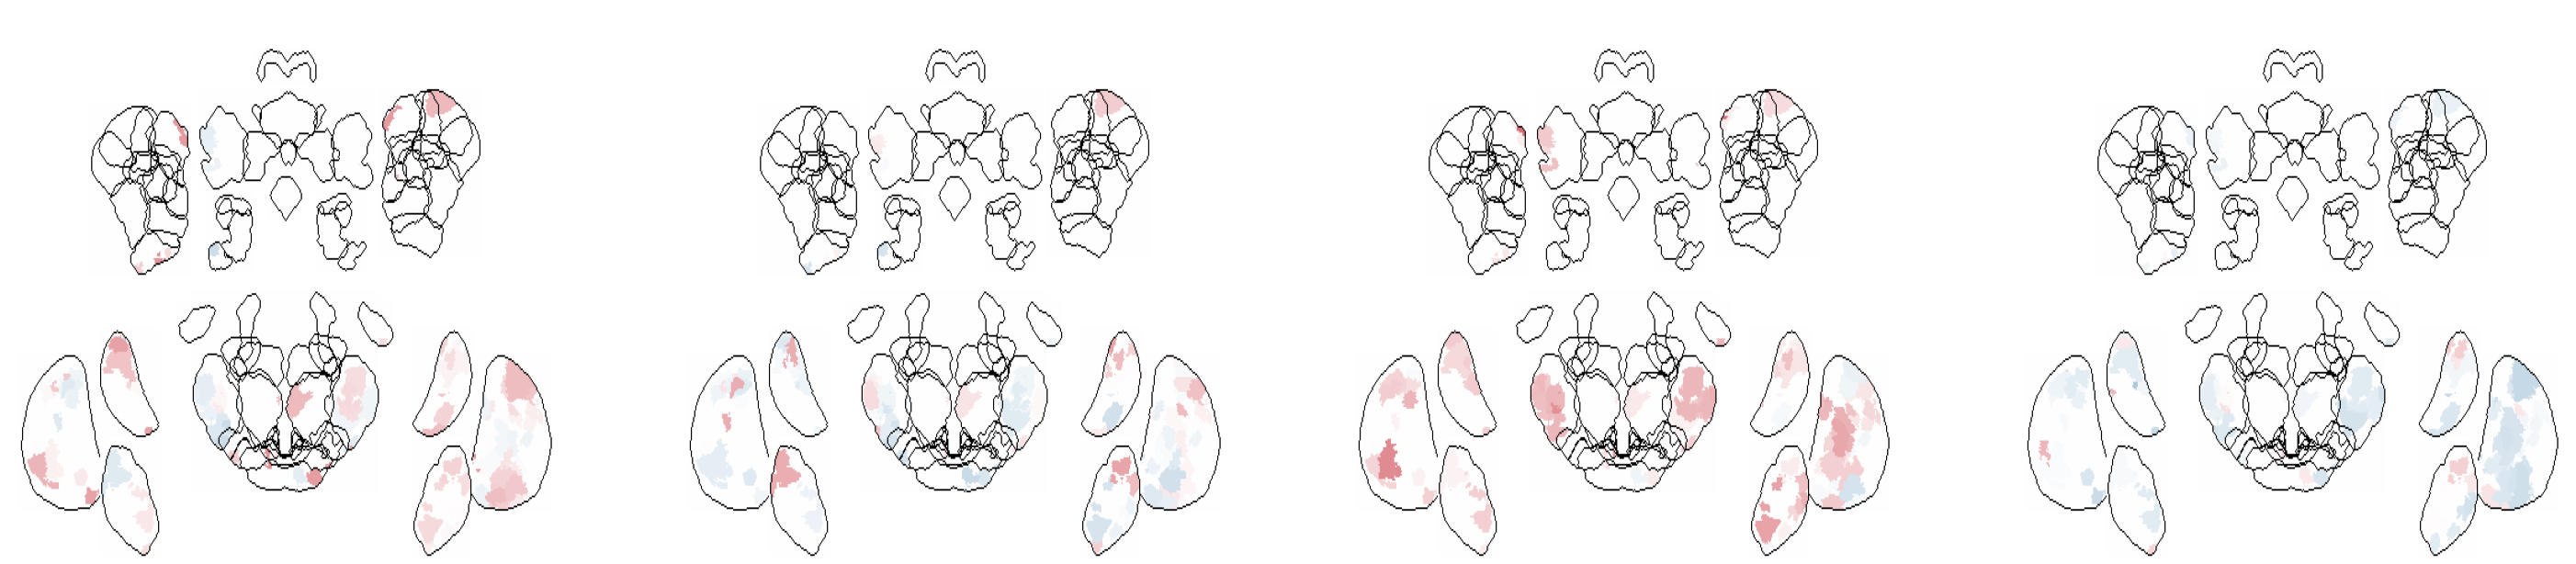

In [79]:
b='dec'
brain=full_res_superclust[b]
fig,axs=plt.subplots(1,4,figsize=(50,50))
for i,tp in enumerate(range_of_interest):
    masked_nonan=np.where(np.isin(giant_labels_anat,roi_of_interest),brain, np.nan)
    masked_nonan=np.nan_to_num(masked_nonan)
    vmax=5
    temp=explode_plot(masked_nonan,vmax,explosion_rois,roi_masks,roi_contours,tp,cmap=cmap_personal)
    axs[i].imshow(temp[170:,:]) #this was made with cmap=hot
    axs[i].axis('off')
#     axs[i].set_title(f'{tp}',fontsize=50)
    axs[i].set_aspect(ax_as)
# plt.savefig(os.path.join(save_dir,f'explosion_{b}_nonsig.png'), dpi=300, bbox_inches='tight')

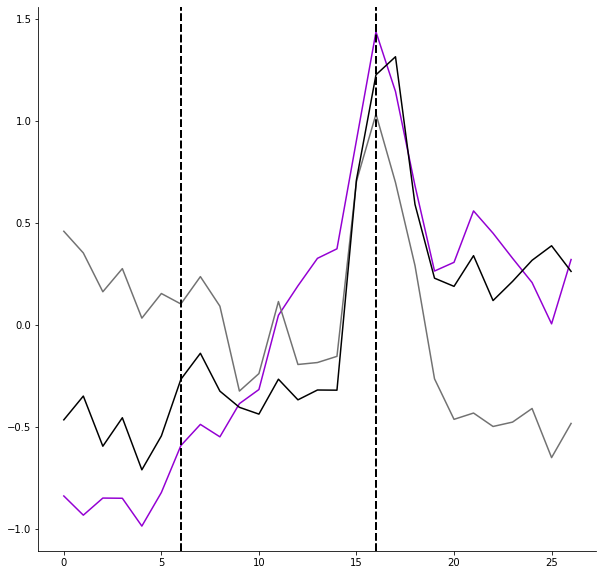

In [80]:
fig,axs=plt.subplots(figsize=(10,10))
rois=same
for behave in superclust_dict_z:
    temp=np.mean(superclust_dict_z[behave][rois],axis=0)
    axs.plot(temp,color=behavior_colors[behave], label=behave)
    x1=6;x2=16
    axs.axvline(x=x1, ymin=0, ymax=1, ls='--', color='k', lw=2)
    axs.axvline(x=x2, ymin=0, ymax=1, ls='--', color='k', lw=2)
    axs.spines['top'].set_visible(False)
    axs.spines['right'].set_visible(False)
#     axs.spines['bottom'].set_visible(False)
#     axs.spines['left'].set_visible(False)
# plt.savefig(os.path.join(save_dir,f'time_trace_nonsig.png'), dpi=300, bbox_inches='tight')

In [81]:
data=anova_dict
rows = []
for category in data.keys():
    for cluster_num in data[category].keys():
#         if int(cluster_num) <= 100:
        array_2d =data[category][cluster_num]

        # For dimension 0
        for val in array_2d[0]:
            rows.append({
                'cluster': cluster_num,
                'category': category,
                'time': 'before',
                'dff': val
            })

        # For dimension 1
        for val in array_2d[1]:
            rows.append({
                'cluster': cluster_num,
                'category': category,
                'time': 'during',
                'dff': val
            })

df = pd.DataFrame(rows)

In [82]:
df_filtered = df[df['cluster'].isin(same)]
df_before = df_filtered[df_filtered['time'] == 'before']
df_during = df_filtered[df_filtered['time'] == 'during']

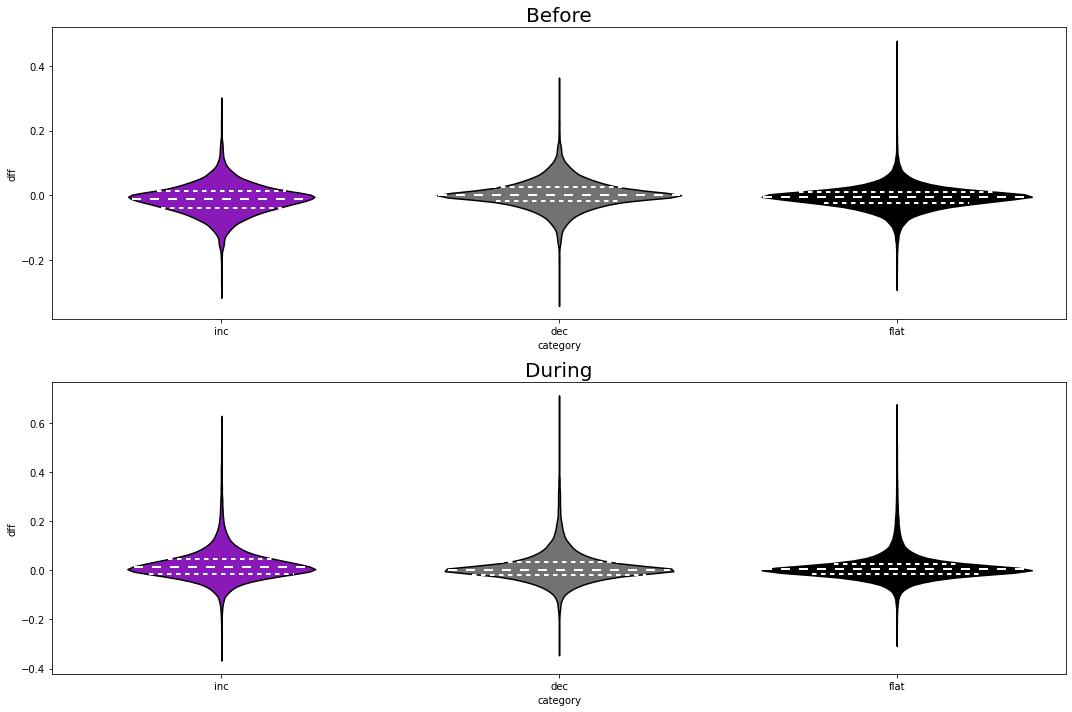

In [83]:
fig, (ax1,ax2) = plt.subplots(2,1,figsize=(15, 10))
sns.violinplot(
    data=df_before,
    x='category',
    y='dff',
    split=False,  # Set to True if you want split violins within categories
    palette=behavior_colors,
    ax=ax1, 
    inner="quart"

)
for artist in ax1.get_children():
    if isinstance(artist, plt.Line2D):
        # These are the quartile lines inside the violins
        artist.set_color('white')
        artist.set_linewidth(2)
ax1.set_title('Before',fontsize=20)

sns.violinplot(
    data=df_during,
    x='category',
    y='dff',
    split=False,  # Set to True if you want split violins within categories
    palette=behavior_colors,
    ax=ax2, 
    inner="quart"

)
for artist in ax2.get_children():
    if isinstance(artist, plt.Line2D):
        # These are the quartile lines inside the violins
        artist.set_color('white')
        artist.set_linewidth(2)
ax2.set_title('During',fontsize=20)
# plt.savefig(os.path.join(save_dir,f'violin_nonsig.png'), dpi=300, bbox_inches='tight')
fig.tight_layout()

In [84]:
same

array([ 43,  49,  60,  69,  76,  78,  84, 106, 107, 110, 114, 121, 130,
       141, 144, 150, 161, 171, 176, 179, 184, 200, 217, 223, 246, 247,
       254, 258, 260, 262, 269, 274, 293, 296, 297, 301, 302, 308, 309,
       313, 325, 327, 331, 338, 340, 342, 346, 347, 355, 357, 359, 366,
       367, 371, 373, 375, 391, 392, 393, 396, 400, 405, 409, 410, 412,
       413, 415, 418, 420, 429, 430, 444, 447, 449, 457, 459, 463, 468,
       472, 473, 477, 479, 483, 485, 487, 491, 493, 494, 499])

In [85]:
reg=np.arange(500)
without=reg[~np.isin(reg,same)]

In [86]:
behaviored_superclust={}
for behave in superclust_dict:
    behaviored_superclust[behave]=superclust_dict[behave][without,15:41]

In [87]:
behaviored_superclust['dec'].shape

(411, 26)

In [88]:
behaviored_giant_superclust=[]
for i in range(behaviored_superclust['inc'].shape[0]):
    clust_behave=np.vstack((behaviored_superclust['inc'][i,:],behaviored_superclust['dec'][i,:],behaviored_superclust['flat'][i,:]))
    behaviored_giant_superclust.append(clust_behave)
behaviored_giant_superclust=np.vstack(behaviored_giant_superclust)
print(behaviored_giant_superclust.shape)

(1233, 26)


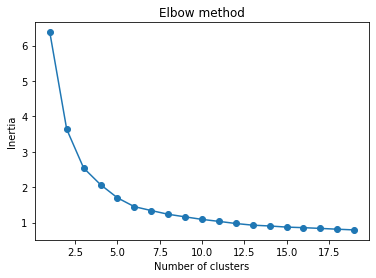

In [89]:
data=gaussian_filter1d(behaviored_giant_superclust,sigma=1)
# data=giant_superclust

inertias = []
ks = 20

for i in range(1,ks):
    kmeans = sklearn.cluster.KMeans(n_clusters=i)
    kmeans.fit(data)
    inertias.append(kmeans.inertia_)

plt.plot(range(1,ks), inertias, marker='o')
plt.title('Elbow method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
# plt.savefig(os.path.join(save_dir,f'k_elbow_smooth.png'), dpi=300, bbox_inches='tight')
plt.show()

In [90]:
n_clusters=6
kmeans = sklearn.cluster.KMeans(n_clusters=n_clusters)
kmeans.fit(data)
np.shape(kmeans.labels_)

(1233,)

In [91]:
labels=kmeans.labels_
sort_array=np.argsort(labels)
k_clustered=data[sort_array]

In [92]:
rainbow_color=np.asarray(['#EF476F', '#F78C6B', '#FFD166', '#06D6A0','#118AB2','#6A4C93', '#6d0d25']) 
rainbow_color=rainbow_color[:n_clusters]
# cmap_rainbow = matplotlib.colors.LinearSegmentedColormap.from_list(
#     'cmap', rainbow_color)
cmap_rainbow = matplotlib.colors.ListedColormap(rainbow_color)

In [93]:
np.shape(k_clustered)

(1233, 26)

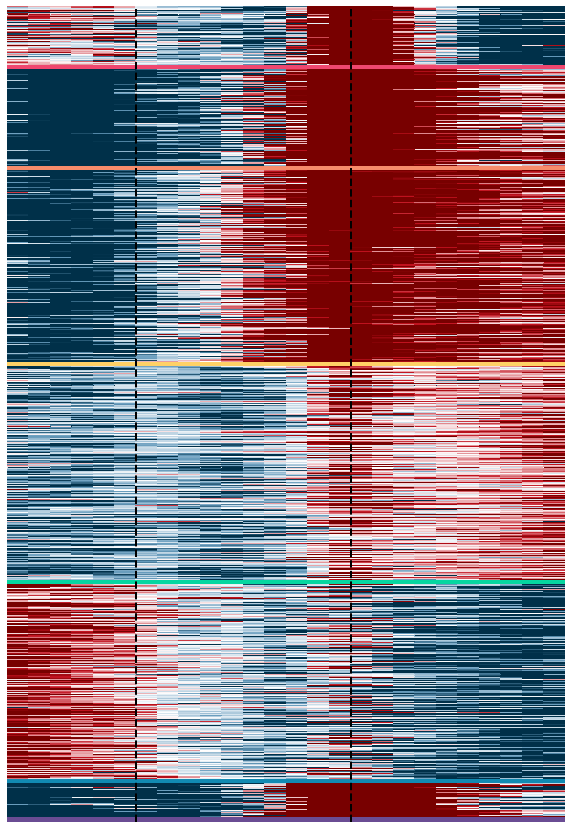

In [94]:
to_plot=k_clustered
color_map=rainbow_color
clustered=np.unique(labels)
vmax=0.01
vmin=-0.01
fig,axs=plt.subplots(figsize=(10,15))
sns.heatmap(to_plot,yticklabels=[],xticklabels=[],
            cmap=cmap_personal, cbar=False, ax=axs, center=0,vmax=vmax,vmin=vmin)
superclust_size=np.shape(to_plot)[0]
total=0
axs.axhline(y=np.shape(k_clustered)[0], color=color_map[-1], lw=10)
for cluss in clustered:
    clus_size=np.shape(labels[labels==cluss])[0]
    total+=clus_size
    if total<superclust_size:
        axs.axhline(y=(total), color=color_map[cluss], lw=4)
x1=6;x2=16
axs.axvline(x=x1, ymin=0, ymax=1, ls='--', color='k', lw=2)
axs.axvline(x=x2, ymin=0, ymax=1, ls='--', color='k', lw=2)
# plt.savefig(os.path.join(save_dir,f'k_{n_clusters}clusters_smooth_without.png'), dpi=300, bbox_inches='tight')

In [95]:
types=np.zeros((behaviored_superclust['inc'].shape[0], len(behaviored_superclust)))
for clus in clustered:
    clus_in=np.where(labels==clus)[0]
    remains=np.remainder(clus_in,3)
    which=np.full(*np.shape(remains),str)
    
    for i in range(len(superclust_dict_z)):
        if i==1:
            behave='dec'
        elif i==2:
            behave='flat'
        else:
            behave='inc'
        which[np.where(remains==i)]=behave
    for i,el in enumerate(clus_in):
        clus_name=int(np.ceil(el/3))-1
        behave=which[i]
        if behave=='flat':
            types[clus_name,0]=clus
        elif behave=='inc':
            types[clus_name,1]=clus
        else:
            types[clus_name,2]=clus

<AxesSubplot:>

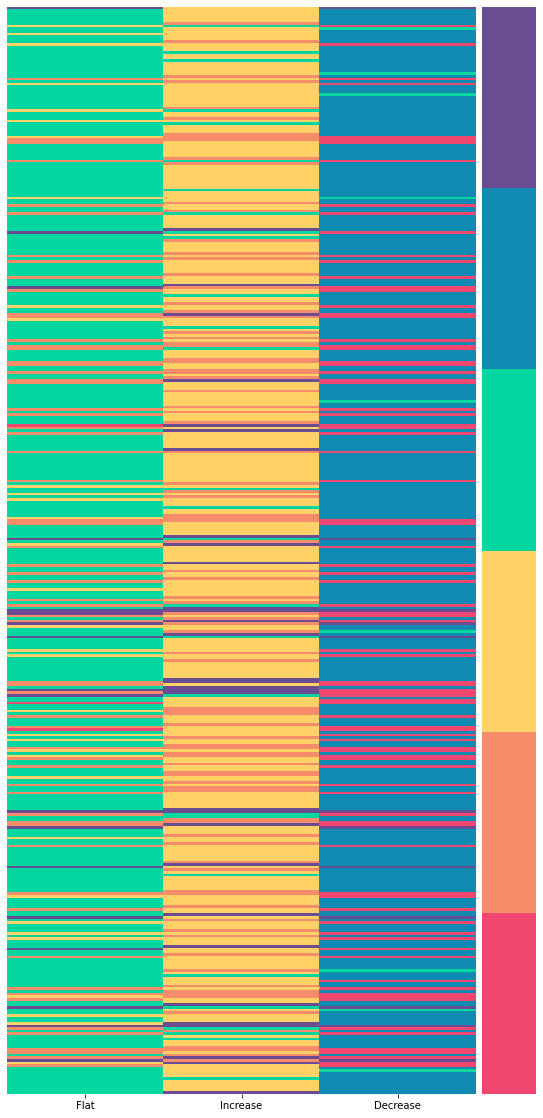

In [96]:
fig, ax = plt.subplots(figsize=(10, 20))  # Tall and narrow for 500x5
# custom_ticks=np.arange(1,(n_clusters+1))
# sns.set(font_scale=1)
sns.heatmap(types, 
            cmap=cmap_rainbow, 
            ax=ax,yticklabels=False, cbar=True,
            xticklabels=['Flat','Increase','Decrease'], 
            cbar_kws={'ticks': [],"pad": 0.01})

# plt.savefig(os.path.join(save_dir,f'k_{n_clusters}types_smooth_without.png'), dpi=300, bbox_inches='tight')

In [97]:
clus_labels={}
for cluster in range(n_clusters):
    clusters_4_look=np.where(labels==cluster)[0]
    clusters_4_look
    clusters_4_look=np.floor(clusters_4_look/3).astype(int)
    print(np.shape(clusters_4_look))
    uniques=np.unique(clusters_4_look)
    uniques[uniques==8]=uniques[-1]
    behave_unqiues=without[uniques]
    print(np.shape(behave_unqiues))
    clus_labels[cluster]=behave_unqiues

(92,)
(89,)
(153,)
(105,)
(295,)
(289,)
(331,)
(295,)
(301,)
(301,)
(61,)
(31,)


In [ ]:
# best_total=[clus_labels[0],clus_labels[1],clus_labels[5]]
common_values=reduce(np.intersect1d, best_total)
out=np.arange(500)[~np.isin(np.arange(500),common_values)]

In [100]:
common_values

array([129, 158, 178, 181, 189, 228, 235, 287, 288, 291, 353, 462, 482])

In [101]:
red=['#EF476F', '#F58EA6', '#FAC7D3']
orange=['#F78C6B', '#FAB49E', '#FCD2C5']
yellow=['#FFD166', '#FFE099', '#FFEDC2']
green=['#06D6A0', '#24F9C1', '#74FBD7']
blue=['#118AB2', '#1FB7EA', '#7CD5F3']
purple=['#6A4C93','#9478BA', '#BFAED5']
color_dict={'0':red,'1':orange,'2':yellow,'3':green,'4':blue,'5':purple}

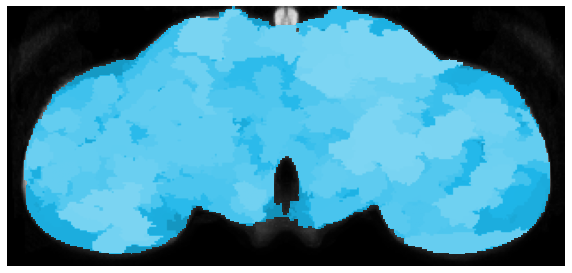

In [102]:
c=4
giant_labels_anat=giant_total_labels.reshape(314,146,91)
labels_anat_sub_total=np.where(np.isin(giant_labels_anat,clus_labels[c]),giant_labels_anat,np.nan)
# labels_anat_sub_total=np.where(np.isin(giant_labels_anat,top_indices[0]),giant_labels_anat,np.nan)   
fig,ax=plt.subplots(figsize=(10,10))
ax.imshow(np.nanmax(fixed.numpy(),axis=-1).T,cmap='Greys_r')
cmap_single = matplotlib.colors.LinearSegmentedColormap.from_list(
    'cmap', color_dict[str(c)])
ax.imshow(np.nanmax(labels_anat_sub_total,axis=-1).T,cmap=cmap_single)
ax.axis('off');
# plt.savefig(os.path.join(save_dir,f'k_{cluster}_areas_without.png'), dpi=300, bbox_inches='tight')

In [103]:
clus_labels[1]

array([  7,  14,  27,  29,  39,  44,  51,  52,  53,  61,  63,  81,  85,
        96, 101, 103, 112, 118, 125, 128, 129, 131, 137, 139, 142, 143,
       149, 151, 154, 155, 157, 158, 163, 169, 172, 177, 178, 181, 189,
       190, 201, 203, 206, 208, 215, 216, 218, 227, 228, 235, 238, 241,
       250, 252, 257, 261, 264, 267, 277, 280, 287, 288, 291, 303, 304,
       305, 311, 317, 320, 321, 323, 324, 329, 333, 334, 337, 341, 343,
       353, 358, 360, 365, 370, 380, 383, 394, 395, 402, 408, 417, 421,
       428, 436, 442, 445, 446, 448, 455, 462, 465, 474, 475, 478, 481,
       482])

NameError: name 'superclust_dict_z_five_sec' is not defined

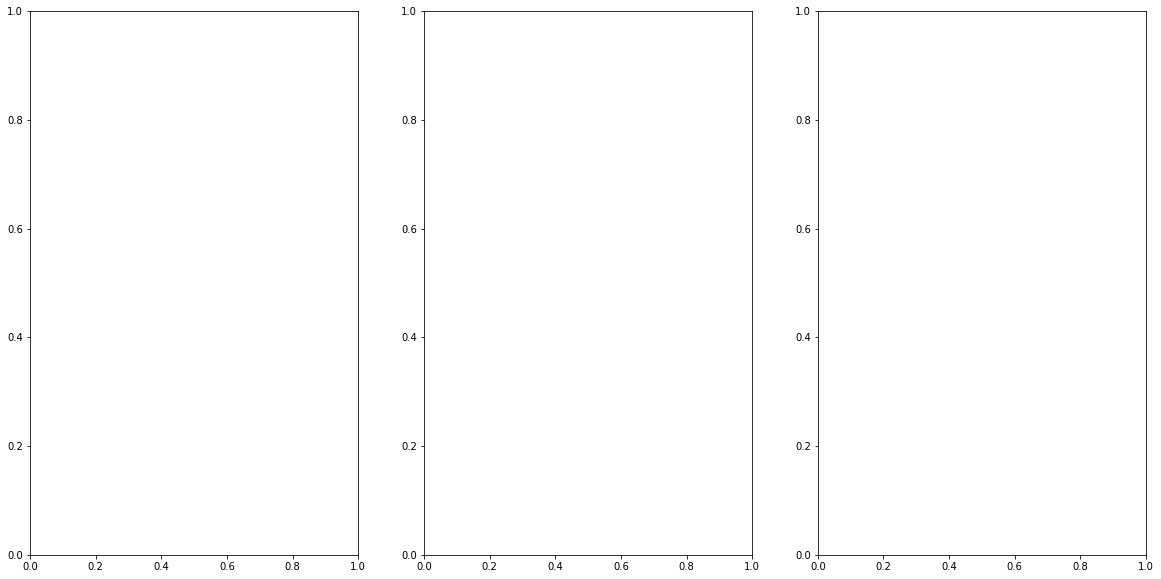

In [104]:
ax_ap=0.05
vmax=2
vmin=-2
not_in=~np.isin(np.arange(500),rois)
fig,ax=plt.subplots(1,3,figsize=(20,10))
b='inc'
ax[0].imshow(superclust_dict_z_five_sec[b][clus_labels[c],:],cmap=cmap_personal,vmax=vmax,vmin=vmin)
ax[0].set_aspect(ax_ap)
b='dec'
ax[1].imshow(superclust_dict_z_five_sec[b][clus_labels[c],:],cmap=cmap_personal,vmax=vmax,vmin=vmin)
ax[1].set_aspect(ax_ap)
b='flat'
ax[2].imshow(superclust_dict_z_five_sec[b][clus_labels[c],:],cmap=cmap_personal,vmax=vmax,vmin=vmin)
ax[2].set_aspect(ax_ap)

In [ ]:
ax_ap=0.03
vmax=2
vmin=-2
not_in=~np.isin(np.arange(500),clus_labels[c])
fig,ax=plt.subplots(1,3,figsize=(20,10))
b='inc'
ax[0].imshow(superclust_dict_z_five_sec[b][not_in,:],cmap=cmap_personal,vmax=vmax,vmin=vmin)
ax[0].set_aspect(ax_ap)
b='dec'
ax[1].imshow(superclust_dict_z_five_sec[b][not_in,:],cmap=cmap_personal,vmax=vmax,vmin=vmin)
ax[1].set_aspect(ax_ap)
b='flat'
ax[2].imshow(superclust_dict_z_five_sec[b][not_in,:],cmap=cmap_personal,vmax=vmax,vmin=vmin)
ax[2].set_aspect(ax_ap)

In [ ]:
ax_ap=0.03
vmax=2
vmin=-2
# not_in=~np.isin(np.arange(500),behave_unqiues)
fig,ax=plt.subplots(1,3,figsize=(20,10))
b='inc'
ax[0].imshow(superclust_dict_z_five_sec[b],cmap=cmap_personal,vmax=vmax,vmin=vmin)
ax[0].set_aspect(ax_ap)
b='dec'
ax[1].imshow(superclust_dict_z_five_sec[b],cmap=cmap_personal,vmax=vmax,vmin=vmin)
ax[1].set_aspect(ax_ap)
b='flat'
ax[2].imshow(superclust_dict_z_five_sec[b],cmap=cmap_personal,vmax=vmax,vmin=vmin)
ax[2].set_aspect(ax_ap)

In [ ]:
fig,axs=plt.subplots(figsize=(10,10))
rois=clus_labels[c]
clus_in,which=which_behave(labels,cluster,superclust_dict)
for behave in superclust_dict_z:
    behave_clusts=clus_in[which==behave]
    real_clus=np.floor(behave_clusts/3).astype(int)
    if real_clus is not []:
        temp=np.mean(superclust_dict_z[behave][real_clus],axis=0)
        axs.plot(temp,color=behavior_colors[behave], label=behave, lw=4)
        x1=6;x2=16
        axs.axvline(x=x1, ymin=0, ymax=1, ls='--', color='k', lw=2)
        axs.axvline(x=x2, ymin=0, ymax=1, ls='--', color='k', lw=2)
        axs.spines['top'].set_visible(False)
        axs.spines['right'].set_visible(False)
#     axs.spines['bottom'].set_visible(False)
#     axs.spines['left'].set_visible(False)
# plt.savefig(os.path.join(save_dir,f'k_{cluster+1}cluster_time_trace_without.png'), dpi=300, bbox_inches='tight')

In [ ]:
clusters=[2,3,5]
of_interest={}
for cluster in clusters:
    clusters_4_look=np.where(labels==cluster)[0]
    clusters_4_look
    clusters_4_look=np.floor(clusters_4_look/3).astype(int)
#     print(np.shape(clusters_4_look))
    uniques=np.unique(clusters_4_look)
    uniques[uniques==8]=uniques[-1]
    behave_unqiues=without[uniques]
#     print(np.shape(behave_unqiues))
    of_interest[cluster]=np.asarray(behave_unqiues)

In [ ]:
best_total=[of_interest[clusters[0]],of_interest[clusters[1]],of_interest[clusters[2]]]
common_values=reduce(np.intersect1d, best_total)
common_values.shape

In [ ]:
np.unique(np.hstack(best_total))

In [ ]:
giant_labels_anat=giant_total_labels.reshape(314,146,91)
labels_anat_sub_total=np.where(np.isin(giant_labels_anat,common_values),giant_labels_anat,np.nan)
# labels_anat_sub_total=np.where(np.isin(giant_labels_anat,top_indices[0]),giant_labels_anat,np.nan)   
fig,ax=plt.subplots(figsize=(10,10))
ax.imshow(np.nanmax(fixed.numpy(),axis=-1).T,cmap='Greys_r')
ax.imshow(np.nanmax(labels_anat_sub_total,axis=-1).T,cmap='Greens_r')
ax.axis('off');
# plt.savefig(os.path.join(save_dir,f'overlap_regions.png'), dpi=300, bbox_inches='tight')


In [ ]:
fig,axs=plt.subplots(figsize=(10,10))
rois=common_values
for behave in superclust_dict_z:
    temp=np.mean(superclust_dict_z[behave][rois],axis=0)
    axs.plot(temp,color=behavior_colors[behave], label=behave)
    x1=6;x2=16
    axs.axvline(x=x1, ymin=0, ymax=1, ls='--', color='k', lw=2)
    axs.axvline(x=x2, ymin=0, ymax=1, ls='--', color='k', lw=2)
    axs.spines['top'].set_visible(False)
    axs.spines['right'].set_visible(False)
# plt.savefig(os.path.join(save_dir,f'overlap_regions_traces.png'), dpi=300, bbox_inches='tight')


In [ ]:
b='inc'
brain=full_res_superclust[b]
roi_of_interest=common_values
ax_as=1.5
# range_of_interest=np.arange(13,18).astype(int)
range_of_interest=np.asarray([3,14,15,23])
fig,axs=plt.subplots(1,4,figsize=(50,50))
for i,tp in enumerate(range_of_interest):
    masked_nonan=np.where(np.isin(giant_labels_anat,roi_of_interest),brain, np.nan)
    masked_nonan=np.nan_to_num(masked_nonan)
    vmax=5
    temp=explode_plot(masked_nonan,vmax,explosion_rois,roi_masks,roi_contours,tp,cmap=cmap_personal)
    axs[i].imshow(temp[170:,:]) #this was made with cmap=hot
    axs[i].axis('off')
#     axs[i].set_title(f'{tp}',fontsize=50)
    axs[i].set_aspect(ax_as)
# plt.savefig(os.path.join(save_dir,f'explosion_{b}_clusteroverlap.png'), dpi=300, bbox_inches='tight')
b='dec'
brain=full_res_superclust[b]
fig,axs=plt.subplots(1,4,figsize=(50,50))
for i,tp in enumerate(range_of_interest):
    masked_nonan=np.where(np.isin(giant_labels_anat,roi_of_interest),brain, np.nan)
    masked_nonan=np.nan_to_num(masked_nonan)
    vmax=5
    temp=explode_plot(masked_nonan,vmax,explosion_rois,roi_masks,roi_contours,tp,cmap=cmap_personal)
    axs[i].imshow(temp[170:,:]) #this was made with cmap=hot
    axs[i].axis('off')
#     axs[i].set_title(f'{tp}',fontsize=50)
    axs[i].set_aspect(ax_as)
# plt.savefig(os.path.join(save_dir,f'explosion_{b}_clusteroverlap.png'), dpi=300, bbox_inches='tight')
b='flat'
brain=full_res_superclust[b]
fig,axs=plt.subplots(1,4,figsize=(50,50))
for i,tp in enumerate(range_of_interest):
    masked_nonan=np.where(np.isin(giant_labels_anat,roi_of_interest),brain, np.nan)
    masked_nonan=np.nan_to_num(masked_nonan)
    vmax=5
    temp=explode_plot(masked_nonan,vmax,explosion_rois,roi_masks,roi_contours,tp,cmap=cmap_personal)
    axs[i].imshow(temp[170:,:]) #this was made with cmap=hot
    axs[i].axis('off')
#     axs[i].set_title(f'{tp}',fontsize=50)
    axs[i].set_aspect(ax_as)
# plt.savefig(os.path.join(save_dir,f'explosion_{b}_clusteroverlap.png'), dpi=300, bbox_inches='tight')

In [ ]:
clust=0
test=of_interest[clust][~np.isin(of_interest[clust], common_values)]
cmap_single = matplotlib.colors.LinearSegmentedColormap.from_list(
    'cmap', color_dict[str(clust)])

In [ ]:
giant_labels_anat=giant_total_labels.reshape(314,146,91)
labels_anat_sub_total=np.where(np.isin(giant_labels_anat,test),giant_labels_anat,np.nan)
# labels_anat_sub_total=np.where(np.isin(giant_labels_anat,top_indices[0]),giant_labels_anat,np.nan)   
fig,ax=plt.subplots(figsize=(10,10))
ax.imshow(np.nanmax(fixed.numpy(),axis=-1).T,cmap='Greys_r')
ax.imshow(np.nanmax(labels_anat_sub_total,axis=-1).T,cmap=cmap_single)
ax.axis('off');

In [ ]:
fig,axs=plt.subplots(figsize=(10,10))
rois=test
for behave in superclust_dict_z:
    temp=np.mean(superclust_dict_z[behave][rois],axis=0)
    axs.plot(temp,color=behavior_colors[behave], label=behave)
    x1=6;x2=16
    axs.axvline(x=x1, ymin=0, ymax=1, ls='--', color='k', lw=2)
    axs.axvline(x=x2, ymin=0, ymax=1, ls='--', color='k', lw=2)
    axs.spines['top'].set_visible(False)
    axs.spines['right'].set_visible(False)
# plt.savefig(os.path.join(save_dir,f'overlap_regions_traces.png'), dpi=300, bbox_inches='tight')


In [ ]:
b='inc'
brain=full_res_superclust[b]
roi_of_interest=test
ax_as=1.5
# range_of_interest=np.arange(13,18).astype(int)
range_of_interest=np.asarray([3,14,15,23])
fig,axs=plt.subplots(1,4,figsize=(50,50))
for i,tp in enumerate(range_of_interest):
    masked_nonan=np.where(np.isin(giant_labels_anat,roi_of_interest),brain, np.nan)
    masked_nonan=np.nan_to_num(masked_nonan)
    vmax=5
    temp=explode_plot(masked_nonan,vmax,explosion_rois,roi_masks,roi_contours,tp,cmap=cmap_personal)
    axs[i].imshow(temp[170:,:]) #this was made with cmap=hot
    axs[i].axis('off')
#     axs[i].set_title(f'{tp}',fontsize=50)
    axs[i].set_aspect(ax_as)
# plt.savefig(os.path.join(save_dir,f'explosion_{b}_clusteroverlap.png'), dpi=300, bbox_inches='tight')
b='dec'
brain=full_res_superclust[b]
fig,axs=plt.subplots(1,4,figsize=(50,50))
for i,tp in enumerate(range_of_interest):
    masked_nonan=np.where(np.isin(giant_labels_anat,roi_of_interest),brain, np.nan)
    masked_nonan=np.nan_to_num(masked_nonan)
    vmax=5
    temp=explode_plot(masked_nonan,vmax,explosion_rois,roi_masks,roi_contours,tp,cmap=cmap_personal)
    axs[i].imshow(temp[170:,:]) #this was made with cmap=hot
    axs[i].axis('off')
#     axs[i].set_title(f'{tp}',fontsize=50)
    axs[i].set_aspect(ax_as)
# plt.savefig(os.path.join(save_dir,f'explosion_{b}_clusteroverlap.png'), dpi=300, bbox_inches='tight')

In [ ]:
superclust_dict_z[behave].shape

In [ ]:
pca=PCA()

In [ ]:
%%time 
behave='inc'
pca_result = pca.fit_transform(superclust_dict_z[behave])
print(np.shape(pca_result))
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

print(f"First 5 PCs explain: {cumulative_variance[:5]*100}% of variance")

In [ ]:
# 1. Plot explained variance
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(explained_variance_ratio[:10], 'bo-')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Variance Explained by Each PC')

plt.subplot(1, 2, 2)
plt.plot(cumulative_variance[:10], 'ro-')
plt.xlabel('Principal Component')
plt.ylabel('Cumulative Variance')
plt.title('Cumulative Variance Explained')
plt.show()

# 2. Examine the principal components (loadings)
# These show which timepoints contribute most to each PC
s,e,b = 0,5,1
plt.figure(figsize=(15, 4))
for i,v in enumerate(np.arange(s,e,b)):
    plt.subplot(1, (e-s), i+1)
    plt.plot(pca.components_[v])
    plt.title(f'PC{v} Loadings\n({explained_variance_ratio[v]*100:.1f}% variance)')
    plt.xlabel('Timepoint')
    plt.ylabel('Loading')
    plt.ylim(-0.5,1)
plt.tight_layout()
plt.show()

In [ ]:
np.shape(pca.components_)

In [ ]:
atlas = brainsss.load_roi_atlas()
explosion_rois = brainsss.load_explosion_groups()
all_rois = brainsss.unnest_roi_groups(explosion_rois)
roi_masks = brainsss.make_single_roi_masks(all_rois, atlas)
roi_contours = brainsss.make_single_roi_contours(roi_masks, atlas)

In [ ]:
color_map_color_1=np.asarray(['#780000','#C1121F','#E0898F','#F0C4C7','#FFFFFF','#D9E6EF','#B3CDDE','#669BBC', '#003049'])[::-1]
cmap_personal = matplotlib.colors.LinearSegmentedColormap.from_list(
    'cmap', color_map_color_1)

In [ ]:
full_res_PCA=[]
n_clusters=500
cluster_brain=pca_result
brain=cluster_brain.T
cluster_labels=giant_total_labels.T
n_tp = brain.shape[0]
n_clusters = brain.shape[1]
brain_dims=[314,146,91]

colored_by_betas = np.zeros((n_tp, brain_dims[0]*brain_dims[1]*brain_dims[2]))
colored_by_betas = brain[:, cluster_labels]  # Shape: (n_tp, n_voxels)
colored_by_betas = colored_by_betas.reshape(n_tp, brain_dims[0], brain_dims[1], brain_dims[2])
#     for cluster_num in range(n_clusters):
#         cluster_mask = cluster_labels==cluster_num
# #         print(np.shape(cluster_mask))
#         colored_by_betas[:,cluster_mask] = brain[:,cluster_num,np.newaxis]
colored_by_betas = colored_by_betas.reshape(n_tp,brain_dims[0],brain_dims[1],brain_dims[2])
full_res_PCA=np.asarray(colored_by_betas)

In [ ]:
np.shape(full_res_PCA)

In [ ]:
brain=full_res_PCA
input_canvas = np.ones((500,500,3)) #+.5 #.5 for diverging
data_to_plot = brain[1][:,:,::-1]
vmax = 5 #this was 0.5 for STA <------------
explosion_map = brainsss.place_roi_groups_on_canvas(explosion_rois,
                                                    roi_masks,
                                                    roi_contours,
                                                    data_to_plot,
                                                    input_canvas,
                                                    vmax=vmax,
                                                    cmap=cmap_personal, diverging=True)#'hot')

In [ ]:
plt.subplots(figsize=(10,10))
plt.imshow(explosion_map[170:,:]) #this was made with cmap=hot
plt.axis('off')